In [1]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint, choice



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'

DIR_TRAINED = "TRAINED_MODELS"

SAMPLING = '15min'
SAMPLING_MIN = 15
MONTHS_HISTORY = 8

# CREATION GRAPH

In [2]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [3]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,37.22,37.22,96.02,96.02,37.22,36.12,58.80,38.74,25.23,1.10,4.28,6.61,2.62,19.48,0.59,25.23
2024-01-01 00:15:00,84.04,84.04,182.91,182.91,84.04,81.15,98.87,88.68,60.73,2.89,18.22,2.20,7.53,9.56,0.63,60.73
2024-01-01 00:30:00,92.03,92.03,259.18,259.18,92.03,86.86,167.15,93.53,75.66,5.17,11.20,0.00,6.67,71.44,2.18,75.66
2024-01-01 00:45:00,70.26,70.26,211.91,211.91,70.26,66.44,141.64,74.69,48.66,3.82,17.78,0.00,8.24,65.68,1.28,48.66
2024-01-01 01:00:00,37.57,37.57,128.15,128.15,37.57,34.08,90.58,41.40,20.65,3.49,13.43,0.00,7.31,47.85,1.33,20.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 22:45:00,1252.25,1252.25,3474.09,3474.09,1252.25,1197.92,2221.85,1344.22,692.89,54.33,189.42,315.61,146.30,853.54,24.09,692.89
2024-06-28 23:00:00,1132.78,1132.78,3357.47,3357.47,1132.78,1080.89,2224.69,1252.34,572.04,51.89,207.07,301.79,171.45,952.50,19.85,572.04
2024-06-28 23:15:00,1099.54,1099.54,3032.02,3032.02,1099.54,1035.46,1932.48,1196.62,551.90,64.08,209.42,274.14,161.16,717.47,18.40,551.90
2024-06-28 23:30:00,680.84,680.84,2076.58,2076.58,680.84,637.31,1395.74,747.03,362.56,43.53,138.83,135.92,109.73,637.06,11.65,362.56


# GMAN MATRICES

## ADJACENCY MATRIX

In [4]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## INCIDENCE MATRIX

In [5]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: 0.000500000000019598


## NODE MASKS

In [6]:
INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']


## MASK ATTENTION MASK

In [69]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=1):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask

NODE_LIST_IDX = {x:i for i,x in enumerate(NODE_LIST)}
ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)


#for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']:
#    ATT_MASK[NODE_LIST_IDX[node_idx], NODE_LIST_IDX[node_idx]] = True

ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")

ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)

ATT_MASK_DF

--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1
MR_A,1,0,1,1,0,1,1,1,1,1,1,1,1,1,1,1
HR_B,1,1,0,0,1,1,1,1,1,1,1,1,1,1,1,1
MR_B,1,0,1,0,1,1,0,1,1,1,1,1,1,1,1,1
C,1,1,1,1,0,0,1,1,1,0,1,1,1,1,1,1
D,1,1,1,1,1,0,1,1,0,1,0,0,1,1,1,1
A,1,1,1,1,1,1,0,0,1,1,1,1,1,0,0,1
B,1,1,1,1,1,0,1,0,1,1,1,1,0,1,1,1
E,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1,0
S7,1,1,1,1,1,1,1,1,1,0,1,1,1,1,1,1


# PARAMETERS

In [43]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
#FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
#FREQ_MINUTES = FREQ_H*60

NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(30*(24*60/SAMPLING_MIN))          # 1 day
PRED_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 256

STEPS_PER_DAY = int(24*60/SAMPLING_MIN)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 4
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {SAMPLING_MIN} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 15 minutes
Number of nodes: 16
Number of historical steps: 2880
Number of prediction steps: 96
Number of time features: 115
Input dimension: 1
Output dimension: 1
Model dimension: 256
Steps per day: 96
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 4
Dimension of each head: 64


# DATASETS / DATALOADERS

In [44]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, num_his, num_pred):
        self.data = torch.FloatTensor(data)
        self.num_his = num_his
        self.num_pred = num_pred

    def __len__(self):
        return len(self.data) - self.num_his - self.num_pred + 1

    def __getitem__(self, idx):
        # Inputs: The historical window
        x = self.data[idx : idx + self.num_his]
        # Targets: The future window to predict
        y = self.data[idx + self.num_his : idx + self.num_his + self.num_pred]
        return x, y


if DEBUG:
    
    DATA_RAW_DS = TimeSeriesDataset(
        data=DATA_RAW_MODEL.values, 
        num_his=HIST_STEPS, 
        num_pred=PRED_STEPS)
        
    print(f"Dataset size: {len(DATA_RAW_DS)}")
    print(f"Data shape: {DATA_RAW_DS[0][0].shape}")
    print(f"Target shape: {DATA_RAW_DS[0][1].shape}")
    DATA_RAW_DL = DataLoader(DATA_RAW_DS, batch_size=BATCH_SIZE, shuffle=True)

    X, Y = next(iter(DATA_RAW_DL))
    print(f"X.shape: {X.shape}")
    print(f"Y.shape: {Y.shape}")


Dataset size: 14305
Data shape: torch.Size([2880, 16])
Target shape: torch.Size([96, 16])
X.shape: torch.Size([32, 2880, 16])
Y.shape: torch.Size([32, 96, 16])


In [45]:
from sklearn.preprocessing import StandardScaler

SCALER = StandardScaler()
DATA_RAW_MODEL_SCALED = SCALER.fit_transform(DATA_RAW_MODEL.values)

#DATA_RAW_MODEL_DS = TimeSeriesDataset(DATA_RAW_MODEL_SCALED, HIST_STEPS, PRED_STEPS)
total_samples = len(DATA_RAW_MODEL_SCALED)

print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size


train_data = DATA_RAW_MODEL_SCALED[:train_size].copy()
val_data = DATA_RAW_MODEL_SCALED[train_size:].copy()

TSS_TRAIN_DS = TimeSeriesDataset(train_data, HIST_STEPS, PRED_STEPS)
TSS_VAL_DS = TimeSeriesDataset(val_data, HIST_STEPS, PRED_STEPS)

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")



TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")


if DEBUG:
    from random import randint

    _rand_idx = randint(0,len(TSS_TRAIN_DS))
    print()
    print(f"Random index: {_rand_idx}")
    X_real = DATA_RAW_MODEL.values[_rand_idx]
    print()
    print("X real:")
    print(X_real)

    _sample = TSS_TRAIN_DS[_rand_idx]

    X_scaled = _sample[0]
    Y_scaled = _sample[1]

    print()
    print('Data Scaled')
    print(X_scaled[0])


    X_un = (X_scaled * SCALER.scale_) + SCALER.mean_
    print()
    print("Data unscaled")
    print(X_un[0])

Total valid sliding windows: 17280
Train size: 10849
Val size: 481
Train samples: 340 | Val samples: 16

Random index: 10226

X real:
[294.44 294.44 770.09 770.09 294.44 277.57 475.65 306.48 101.17  16.88
  38.4  138.    28.92 166.4    2.76 101.17]

Data Scaled
tensor([-0.2077, -0.2077, -0.2891, -0.2891, -0.2077, -0.2128, -0.3308, -0.2385,
        -0.4353, -0.1038, -0.2310,  0.1559, -0.3978, -0.4380, -0.5171, -0.4353])

Data unscaled
tensor([294.4400, 294.4400, 770.0900, 770.0900, 294.4400, 277.5700, 475.6500,
        306.4800, 101.1700,  16.8800,  38.4000, 138.0000,  28.9200, 166.4000,
          2.7600, 101.1700], dtype=torch.float64)


# MODEL
## ITransformer

In [46]:
class iTransformer(nn.Module):
    """
    iTransformer: Inverted Transformer for Time Series Forecasting.
    
    Ref: iTransformer: Inverted Transformers are Effective for Time Series Forecasting
    """
    def __init__(self, num_variates, hist_steps, pred_steps, d_model=512, n_heads=8, num_layers=2, dropout=0.1, attn_mask=None):
        super(iTransformer, self).__init__()
        
        self.hist_steps = hist_steps
        self.pred_steps = pred_steps
        self.d_model = d_model

        # 1. Embedding: Project the entire lookback window (T) to feature dimension (D)
        # In iTransformer, the MLP acts on the time dimension.
        # Input: (Batch, Num_Variates, Lookback_Len) -> Output: (Batch, Num_Variates, d_model)
        self.embedding = nn.Linear(hist_steps, d_model)
        
        # 2. Transformer Encoder: Captures multivariate correlations
        # The sequence length here is 'Num_Variates', not time steps.
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=n_heads, 
            dim_feedforward=d_model * 4, 
            dropout=dropout, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 3. Projection: Project feature dimension (D) to prediction horizon (S)
        # Input: (Batch, Num_Variates, d_model) -> Output: (Batch, Num_Variates, Pred_Len)
        self.projection = nn.Linear(d_model, pred_steps)

        if attn_mask is not None:
            # We force it to float() right here to prevent TypeErrors later
            print(f"✔️ Att mask set")
            self.register_buffer('attn_mask', attn_mask.float())
        else:
            self.attn_mask = None

    def forward(self, x):
        # x shape: [Batch, hist_steps, Num_Variates]
        
        # Step 1: Invert dimensions to [Batch, Num_Variates, hist_steps]
        # This treats each variate as a "token" and the time series as the "embedding"
        x = x.permute(0, 2, 1) 
        
        # Step 2: Embedding (Linear Layer applied to the time dimension)
        # x shape becomes: [Batch, Num_Variates, d_model]
        x = self.embedding(x)
        
        # Step 3: Multivariate Interaction (Self-Attention)
        # Attention is calculated between variates.
        x = self.encoder(x, mask=self.attn_mask)
        
        # Step 4: Projection to forecast horizon
        # x shape becomes: [Batch, Num_Variates, pred_steps]
        x = self.projection(x)
        
        # Step 5: Invert back to [Batch, pred_steps, Num_Variates] to match ground truth
        x = x.permute(0, 2, 1)
        
        return x

if DEBUG:
    embedding = nn.Linear(HIST_STEPS, D_MODEL)

    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=D_MODEL * 4, 
            batch_first=True,
            norm_first=False # Paper uses Post-LN generally, though Pre-LN is often more stable
        )

    encoder = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS_ENC_DEC)

    projection = nn.Linear(D_MODEL, PRED_STEPS)
 
    for X_d, Y_d in TSS_TRAIN_DL:
            if randint(0,10) == 4:
                break

    print(f"X_d shape: {X_d.shape}")
    print(f"Y_d shape: {Y_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

    X_d = embedding(X_d)
    print(f"X_d shape embedded: {X_d.shape}")

    X_d = encoder(X_d)
    print(f"X_d shape encoded: {X_d.shape}")

    X_d = projection(X_d)
    print(f"X_d shape projected: {X_d.shape}")

    X_d = X_d.permute(0, 2, 1)
    print(f"X_d shape inverted: {X_d.shape}")

X_d shape: torch.Size([32, 2880, 16])
Y_d shape: torch.Size([32, 96, 16])
X_d shape inverted: torch.Size([32, 16, 2880])
X_d shape embedded: torch.Size([32, 16, 256])
X_d shape encoded: torch.Size([32, 16, 256])
X_d shape projected: torch.Size([32, 16, 96])
X_d shape inverted: torch.Size([32, 96, 16])


# TRAINNIG

In [47]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


In [48]:
PATIENCE = 5

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss
        
def train_model(model, device, train_loader, val_loader, optimizer, loss_fn, early_stopping, checkpoint_path, epochs):

    print("Starting Training...")

    for epoch in range(epochs):
        model.train()
        train_loss = 0
        
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                
            optimizer.zero_grad()
                
            # Forward pass
            outputs = model(batch_x)
                
            # Loss calculation
            loss = loss_fn(outputs, batch_y)
            loss.backward()
            optimizer.step()
                
            train_loss += loss.item()
            
        avg_train_loss = train_loss / len(train_loader)
            
        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                outputs = model(batch_x)
                loss = loss_fn(outputs, batch_y)
                val_loss += loss.item()
    
        avg_val_loss = val_loss / len(val_loader)
        
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.5f}, Val Loss: {avg_val_loss:.5f}")


        # Early Stopping
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered. Training stopped.")
            break

    # Load best model
    model.load_state_dict(torch.load(checkpoint_path))
    print("Best model weights loaded for testing.")

    return model

### TRAINING PROCESS

## MODEL ZERO  (MSE ONLY)

In [49]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS
).to(DEVICE)



PREFIX_MODEL = 'itransformer_model_zero'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")



early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

Checkpoint path: TRAINED_MODELS/best_itransformer_model_zero.pth


In [50]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)


OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/30], Train Loss: 0.12630, Val Loss: 0.06982
Validation loss decreased (inf --> 0.069819).  Saving model ...
Epoch [2/30], Train Loss: 0.07223, Val Loss: 0.06655
Validation loss decreased (0.069819 --> 0.066549).  Saving model ...
Epoch [3/30], Train Loss: 0.06590, Val Loss: 0.06130
Validation loss decreased (0.066549 --> 0.061303).  Saving model ...
Epoch [4/30], Train Loss: 0.05802, Val Loss: 0.05959
Validation loss decreased (0.061303 --> 0.059589).  Saving model ...
Epoch [5/30], Train Loss: 0.05397, Val Loss: 0.06787
EarlyStopping counter: 1 out of 5
Epoch [6/30], Train Loss: 0.05072, Val Loss: 0.06388
EarlyStopping counter: 2 out of 5
Epoch [7/30], Train Loss: 0.04795, Val Loss: 0.07037
EarlyStopping counter: 3 out of 5
Epoch [8/30], Train Loss: 0.04413, Val Loss: 0.06906
EarlyStopping counter: 4 out of 5
Epoch [9/30], Train Loss: 0.04157, Val Loss: 0.06497
EarlyStopping counter: 5 out of 5
Early stopping triggered. Training stopped.
Best model weight

## MODEL WITH ATTENTION MASK

In [71]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
).to(DEVICE)



PREFIX_MODEL = 'itransformer_model_att_mask'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = nn.MSELoss()

✔️ Att mask set
Checkpoint path: TRAINED_MODELS/best_itransformer_model_att_mask.pth


In [72]:
MODEL = train_model(
    MODEL,
    DEVICE,
    TSS_TRAIN_DL,
    TSS_VAL_DL,
    optimizer,
    loss_fn,
    early_stopping,
    CHECKPOINT_PATH,
    EPOCHS
)

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/30], Train Loss: 0.12792, Val Loss: 0.07136
Validation loss decreased (inf --> 0.071364).  Saving model ...
Epoch [2/30], Train Loss: 0.07260, Val Loss: 0.07220
EarlyStopping counter: 1 out of 5
Epoch [3/30], Train Loss: 0.06561, Val Loss: 0.06275
Validation loss decreased (0.071364 --> 0.062754).  Saving model ...
Epoch [4/30], Train Loss: 0.05767, Val Loss: 0.08021
EarlyStopping counter: 1 out of 5
Epoch [5/30], Train Loss: 0.05564, Val Loss: 0.06006
Validation loss decreased (0.062754 --> 0.060063).  Saving model ...
Epoch [6/30], Train Loss: 0.04997, Val Loss: 0.06208
EarlyStopping counter: 1 out of 5
Epoch [7/30], Train Loss: 0.04743, Val Loss: 0.05836
Validation loss decreased (0.060063 --> 0.058356).  Saving model ...
Epoch [8/30], Train Loss: 0.04430, Val Loss: 0.05721
Validation loss decreased (0.058356 --> 0.057207).  Saving model ...
Epoch [9/30], Train Loss: 0.03988, Val Loss: 0.05808
EarlyStopping counter: 1 out of 5
Epoch [10/30], Train Loss:

# VALIDATION MODELS

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import seaborn as sns
import random


def validate_model(model, dataloader, criterion, scale, means, device,  channel=None):
    """
    Validates the model and calculates Scaled Loss, Real MAE, and Real RMSE.
    """

    if channel is not None:
        print(f"Channel: {channel}")
    
    model.eval()
    
    total_scaled_loss = 0.0
    total_real_mae = 0.0
    total_real_mse = 0.0  
    
    # Ensure scale and means are Tensors and on the correct device
    if not isinstance(scale, torch.Tensor):
        scale = torch.tensor(scale, dtype=torch.float32)
    if not isinstance(means, torch.Tensor):
        means = torch.tensor(means, dtype=torch.float32)
        
    scale = scale.to(device)
    means = means.to(device)

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X, Y_true_scaled) in enumerate(dataloader):
            
            X = X.to(device)
            Y_true_scaled = Y_true_scaled.to(device)
            
            # Forward Pass
            Y_pred_scaled = model(X)
            
            # Calculate Scaled Loss (MSE for backprop monitoring)
            loss = criterion(Y_pred_scaled, Y_true_scaled)
            total_scaled_loss += loss.item()
            
            # INVERSE TRANSFORM (Z-Scores -> Real Units)
            Y_pred_real = (Y_pred_scaled * scale) + means
            Y_true_real = (Y_true_scaled * scale) + means

            
            if channel is not None:
                Y_pred_real = Y_pred_real[:, :, channel]
                Y_true_real = Y_true_real[:, :, channel]
            
            mae = torch.mean(torch.abs(Y_pred_real - Y_true_real))
            total_real_mae += mae.item()
            
            mse_real = torch.mean((Y_pred_real - Y_true_real) ** 2)
            total_real_mse += mse_real.item()
            
    # Calculate averages over all batches
    avg_scaled_loss = total_scaled_loss / len(dataloader)
    avg_real_mae = total_real_mae / len(dataloader)
    avg_real_mse = total_real_mse / len(dataloader)
    
    # RMSE is the square root of the overall average MSE <-- ADDED
    avg_real_rmse = avg_real_mse ** 0.5
    
    return avg_scaled_loss, avg_real_mae, avg_real_rmse

def validate_plots(model, dataloader, scaler_mean, scaler_std, device, num_nodes_to_plot=3):
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """

    model.eval()
    means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
    scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)


    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
  
    X, Y_true_scaled = next(iter(dataloader))


    # Move to Device
    X = X.to(device)
    B,T,C = X.shape
    
    # 2. Inference
    with torch.no_grad():
        Y_pred_scaled = model(X)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps

    Y_true_real = (Y_true_scaled * scale) + means
    Y_pred_real = (Y_pred_scaled * scale) + means
        

    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Prediction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()

def analyze_itransformer_attention(model, dataloader, feature_names, layer_index=0, device='cuda'):
    """
    Extracts and visualizes the variate-to-variate attention matrix from the iTransformer.
    
    Args:
        model: The trained iTransformer model.
        dataloader: A DataLoader (train, val, or test).
        feature_names: List of names for the channels/variates.
        layer_index: Which Transformer layer to inspect (0 = first layer).
        device: 'cuda' or 'cpu'.
        
    Returns:
        mean_attn_matrix: Numpy array of shape [Num_Variates, Num_Variates]
    """
    model.eval()
    
    # 1. Get one batch of data
    X, _ = next(iter(dataloader))
    X = X.to(device)
    
    with torch.no_grad():
        # 2. Replicate the iTransformer's initial steps
        # Invert dimensions: [Batch, Time, Variates] -> [Batch, Variates, Time]
        X_inv = X.permute(0, 2, 1) 
        
        # Embed the time dimension: [Batch, Variates, d_model]
        X_emb = model.embedding(X_inv)
        
        # 3. Target the specific Transformer layer
        encoder_layer = model.encoder.layers[layer_index]
        self_attn = encoder_layer.self_attn
        
        # 4. Manually trigger the Self-Attention mechanism
        # For self-attention, Query, Key, and Value are all the same (X_emb)
        # need_weights=True forces PyTorch to return the matrix
        # average_attn_weights=True averages the weights across all Attention Heads
        attn_output, attn_weights = self_attn(
            X_emb, 
            X_emb, 
            X_emb, 
            need_weights=True,
            average_attn_weights=True
        )
        
        # attn_weights shape is [Batch, Variates, Variates]
        
    # 5. Average the attention matrix across the entire batch to get a general representation
    mean_attn_matrix = attn_weights.mean(dim=0).cpu().numpy()
    
    # --- Visualization ---
    plt.figure(figsize=(10, 8))
    
    # Plot as a Heatmap
    sns.heatmap(
        mean_attn_matrix, 
        xticklabels=feature_names, 
        yticklabels=feature_names, 
        cmap="viridis", # 'Blues' or 'magma' also work well for attention
        annot=False,    # Set to True to see exact numbers
        fmt=".2f"
    )
    
    plt.title(f"iTransformer Multivariate Attention (Layer {layer_index})")
    plt.xlabel("Key Variate (Provides Information)")
    plt.ylabel("Query Variate (Receives Information)")
    
    # Rotate labels for readability
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    #plt.show()

    
    return mean_attn_matrix, plt.gca()

    """
    Plots the attention weights with proper Node Labels.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader.
        node_names: List of strings ['Node_A', 'Node_B', ...]. 
                    Must match the order of nodes in your Graph/Dataframe.
        layer_idx: Which encoder layer to inspect.
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    
    # 1. Run one batch to get the weights
    # We grab the first batch from the dataloader
    try:
        X, TE, _ = next(iter(dataloader))
    except StopIteration:
        print("DataLoader is empty!")
        return
        
    X, TE = X.to(device), TE.to(device)
    
    with torch.no_grad():
        _ = model(X, TE)
        
    if type_attn == 'spatial':
        print(f"Spatial Attention Weights")
        # 2. Extract Weights from specific layer
        # Access the stored weights from your modified SpatialAttention class
        # Shape: [Batch * Time, Nodes, Nodes]
        if model.encoder_layers[layer_idx].spatial_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].spatial_attn.last_attn_weights
    
    if type_attn == 'temporal':
        print(f"Temporal Attention Weights")
        if model.encoder_layers[layer_idx].temporal_attn.last_attn_weights is None:
            print("⚠️ No weights found! Did you modify SpatialAttention to store them?")
            return

        weights = model.encoder_layers[layer_idx].temporal_attn.last_attn_weights
    
    # 3. Aggregate (Average over Batch and Time) to get the "Global" view
    # Move to CPU and convert to numpy
    avg_weights = weights.mean(dim=0).cpu().numpy()
    
    # 4. Plotting
    plt.figure(figsize=(12, 10))
    
    # Determine labels
    if node_names is not None:
        # Safety Check
        if len(node_names) != avg_weights.shape[0]:
            print(f"⚠️ Warning: Provided {len(node_names)} names but model has {avg_weights.shape[0]} nodes.")
            print("Reverting to numerical indices.")
            xtick = True
            ytick = True
        else:
            xtick = node_names
            ytick = node_names
    else:
        xtick = True # Default numerical indices
        ytick = True

    # Draw Heatmap
    # cmap="viridis" or "Blues" or "Reds"
    sns.heatmap(avg_weights, 
                xticklabels=xtick, 
                yticklabels=ytick, 
                cmap="viridis", 
                square=True,
                annot=False) # Set annot=True if you want to see the exact numbers (can be messy)
    
    plt.title(f"Learned {type_attn} Correlations (Layer {layer_idx})")
    plt.xlabel("Source Node (From)")
    plt.ylabel("Target Node (To)")
    
    # Rotate labels if they are long
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

### MODEL ZERO

Retrieving model from TRAINED_MODELS/itransformer_model_zero_trained.pth
Channel: 0
Channel: 1
Channel: 2
Channel: 3
Channel: 4
Channel: 5
Channel: 6
Channel: 7
Channel: 8
Channel: 9
Channel: 10
Channel: 11
Channel: 12
Channel: 13
Channel: 14
Channel: 15
📊 Visualization for Batch Sample #3


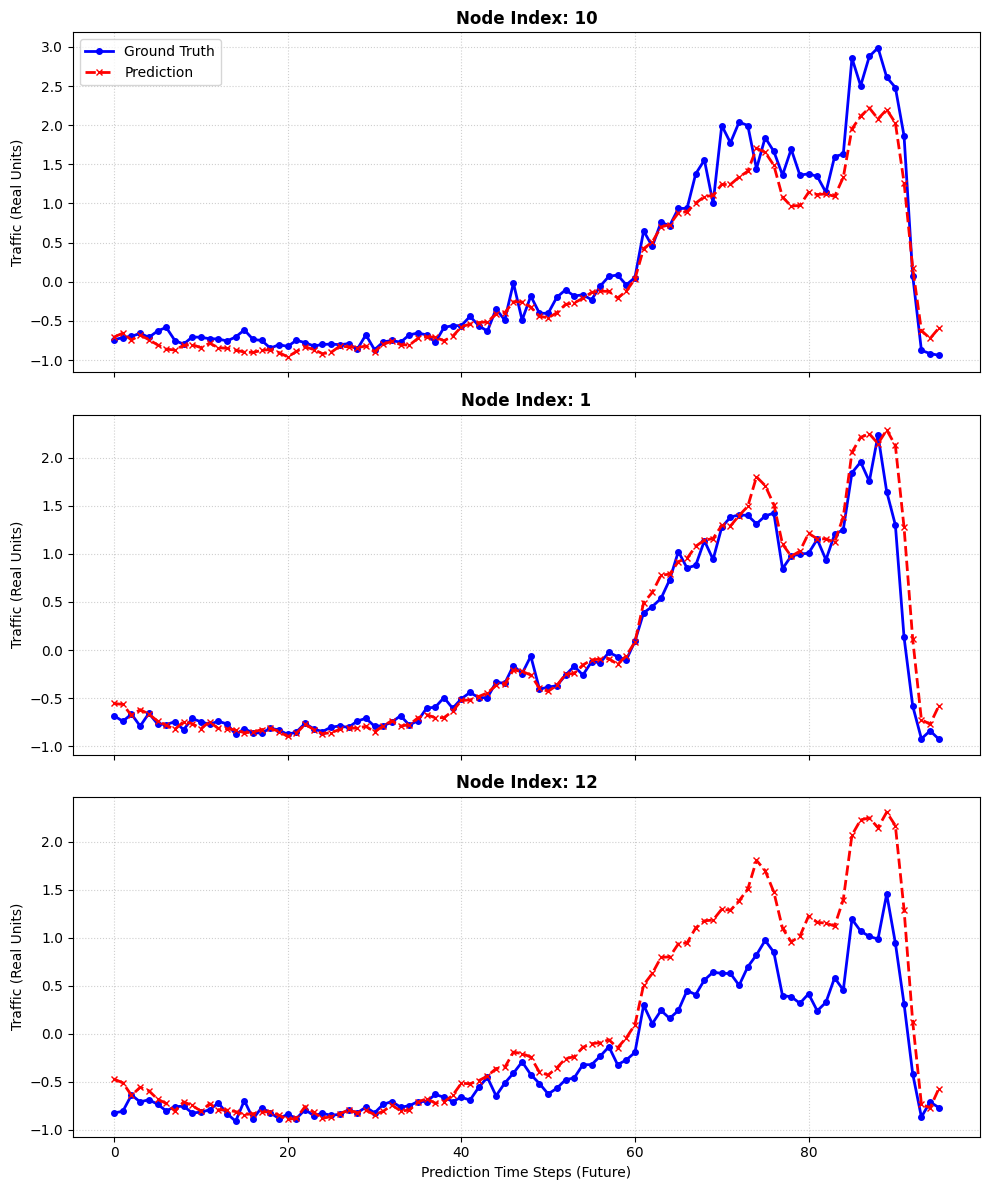

Validation Loss: 0.05958886072039604
Validation MAE: 31.4903206295114
Validation RMSE: 47.364445589529105


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
Loss,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1
MAE,48.8,48.8,123.0,123.0,48.8,47.2,81.2,50.0,31.5,3.4,10.6,21.9,12.2,50.2,1.9,31.5
RMSE,70.7,70.7,172.7,172.7,70.7,68.6,113.2,72.4,47.4,4.4,16.4,29.8,17.4,70.4,2.7,47.4
max_day,1296.9,1296.9,3736.4,3736.4,1296.9,1235.4,2458.0,1401.0,665.9,67.1,183.2,424.6,179.9,1089.7,23.5,665.9
mean_day,373.1,373.1,1088.6,1088.6,373.1,354.3,715.5,404.4,184.4,18.9,50.9,118.9,50.1,304.6,6.5,184.4
pct_err_%,18.9,18.9,15.9,15.9,18.9,19.4,15.8,17.9,25.7,23.6,32.2,25.1,34.8,23.1,41.6,25.7


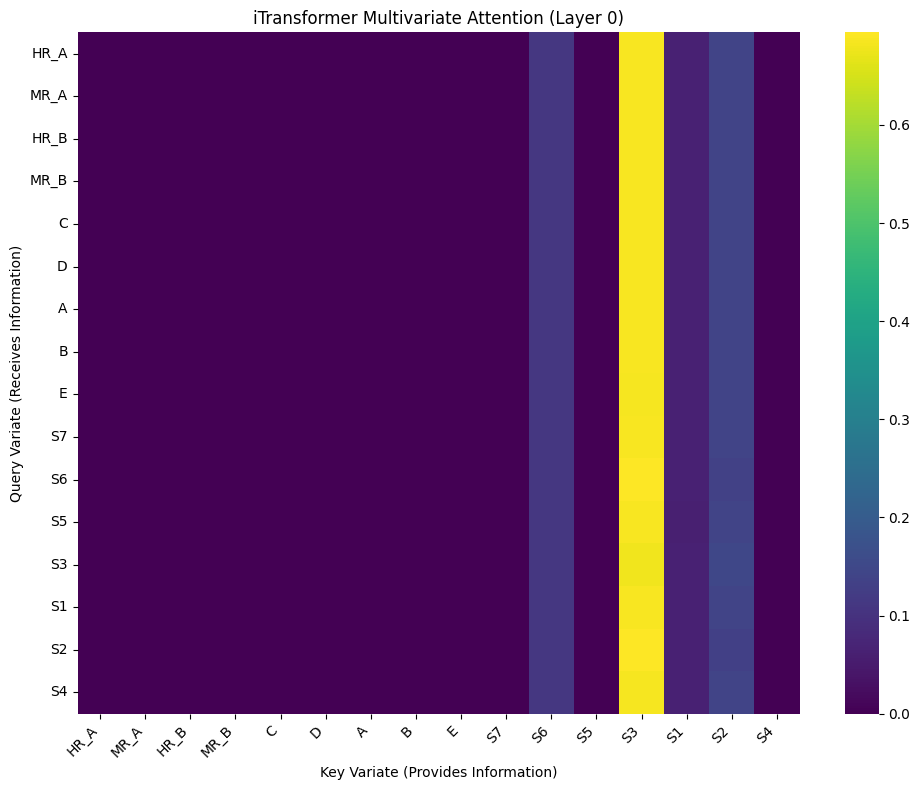

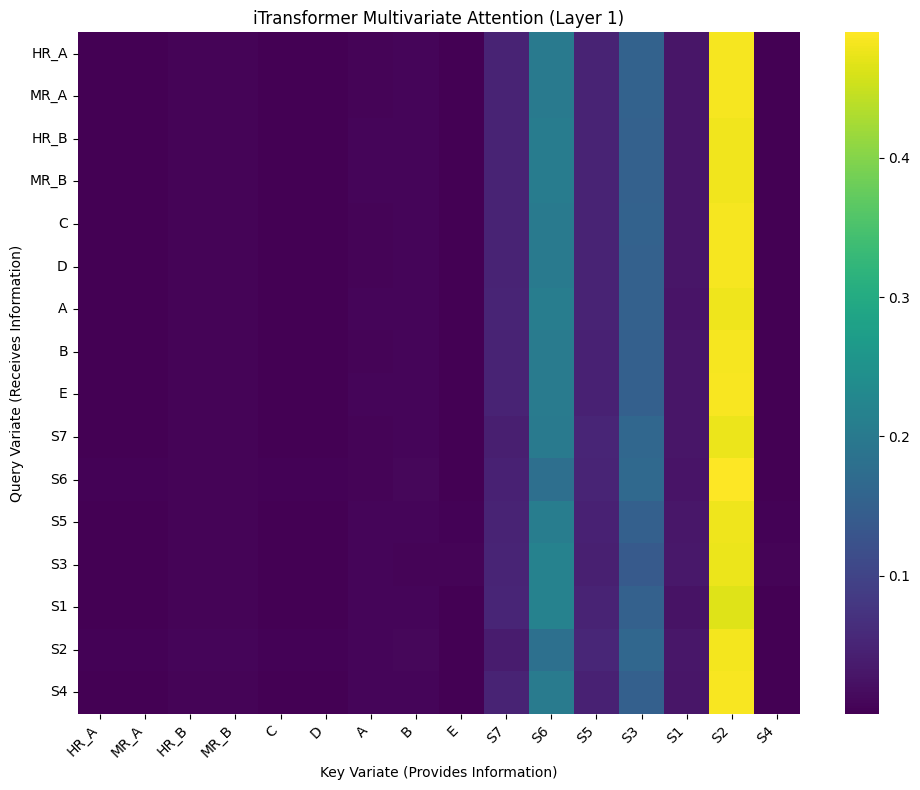

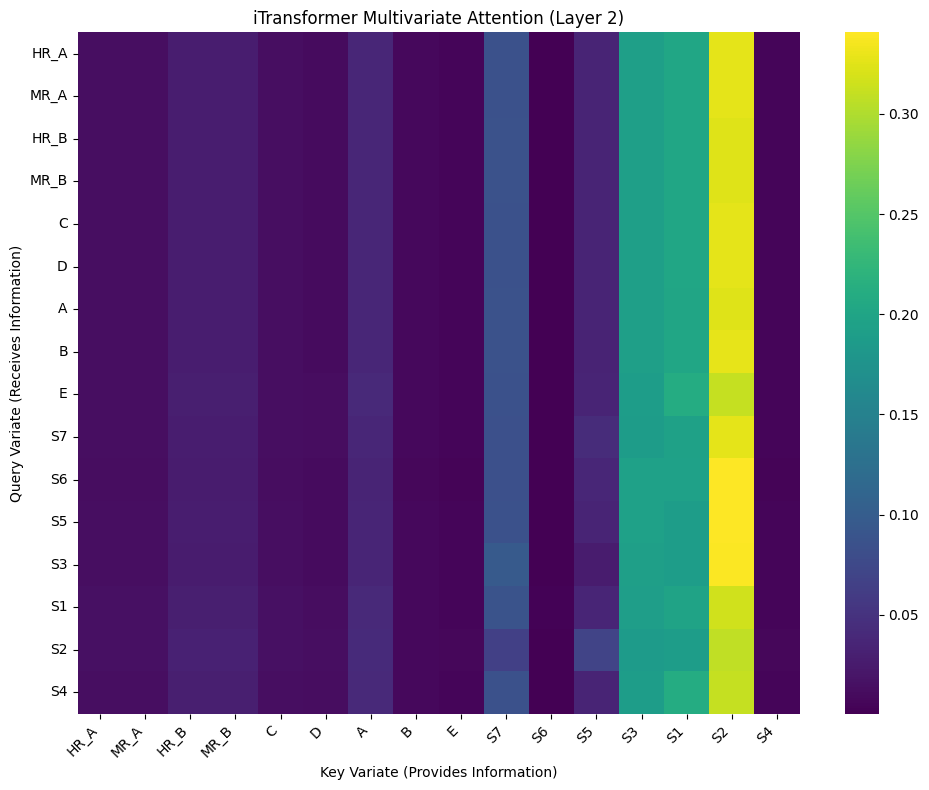

In [ ]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS
)

PREFIX_MODEL = 'itransformer_model_zero'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)


MAX_DAY_NODES = DATA_RAW_MODEL.resample('D').max().mean().to_frame().T
MAX_DAY_NODES.index = ['max_day']

MEAN_DAY_NODES = DATA_RAW_MODEL.resample('D').mean().mean().to_frame().T
MEAN_DAY_NODES.index = ['mean_day']

SCALER_MEAN_T = torch.tensor(SCALER.mean_)
SCALER_STD_T = torch.tensor(SCALER.scale_)


criterion = torch.nn.MSELoss()

ERR_TABLE_NODE = []
for i,node in enumerate(NODE_LIST):
    val_loss, val_mae, val_rmse = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=i)
    ERR_TABLE_NODE.append([val_loss, val_mae, val_rmse])

ERR_TABLE_NODE = pd.DataFrame(ERR_TABLE_NODE, columns=['Loss', 'MAE', 'RMSE'], index=NODE_LIST).T
ERR_TABLE_NODE = pd.concat([
    ERR_TABLE_NODE,
    MAX_DAY_NODES, 
    MEAN_DAY_NODES
    ]).round(2)

ERR_TABLE_NODE = pd.concat([
    ERR_TABLE_NODE,
    (ERR_TABLE_NODE.T['RMSE']/ ERR_TABLE_NODE.T['mean_day']).to_frame().rename(columns={0:'pct_err_%'}).T*100
])

ERR_TABLE_NODE = ERR_TABLE_NODE.round(1)

validate_plots(MODEL, TSS_VAL_DL, SCALER_MEAN_T, SCALER_STD_T, 'cpu', num_nodes_to_plot=3)

axs = []
for i in range(LAYERS_ENC_DEC):
    axs.append(analyze_itransformer_attention(MODEL, TSS_VAL_DL, NODE_LIST, layer_index=i, device='cpu')[1])

val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=None)
print(f"Validation Loss: {val_loss_total}")
print(f"Validation MAE: {val_mae_total}")
print(f"Validation RMSE: {val_rmse_total}")
ERR_TABLE_NODE

### FUTURE PREDICT

Current X shape: torch.Size([1, 2880, 16])
Starting recursive prediction: 2880 steps total.
Model outputs 96 steps at a time -> Requires 30 iterations.


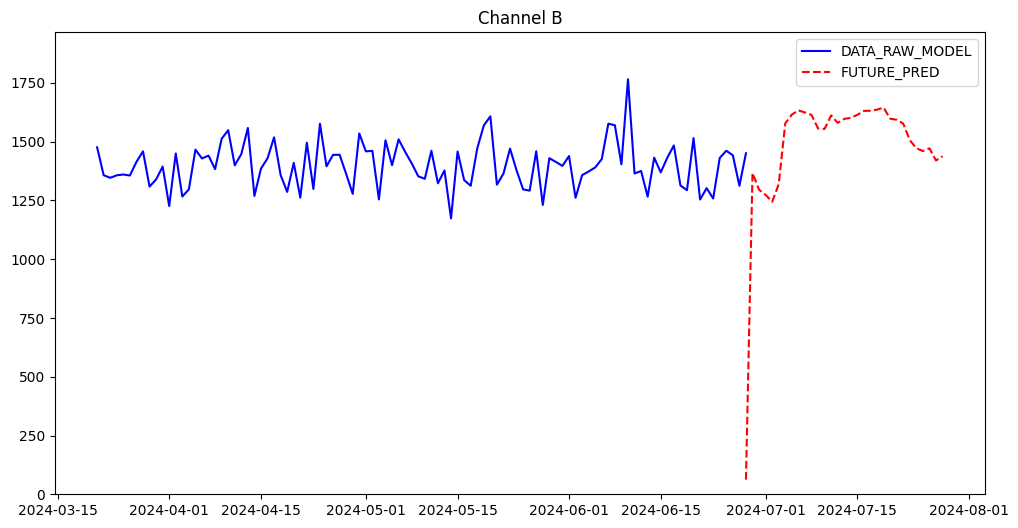

In [83]:
import math

def predict_n_steps_future(model, dataloader, n_steps, scaler_mean, scaler_std, device='cpu'):
    """
    Predicts N steps into the future recursively, starting from the last 
    available sequence in the dataloader.
    
    Args:
        model (nn.Module): The trained PyTorch model.
        dataloader (DataLoader): DataLoader containing the historical data.
        n_steps (int): Total number of future time steps to predict.
        device (str): Device to run inference on.
        
    Returns:
        numpy.ndarray: The predicted future values of shape (n_steps, num_channels).
    """
    model.eval()
    model.to(device)
    means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
    scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)

    
    # 1. Get the very last sequence from the dataloader
    # We iterate through the whole loader to find the final batch
    last_batch_x, last_batch_y = None, None
    for batch_x, batch_y in dataloader:
        last_batch_x = batch_x
        last_batch_y = batch_y


    current_x = last_batch_x[-1:].to(device) 
    print(f"Current X shape: {current_x.shape}")
    
    # Determine lengths from the data
    seq_len = current_x.shape[1]
    pred_len = last_batch_y.shape[1]
    
    # Calculate how many iterations we need
    iterations = math.ceil(n_steps / pred_len)
    print(f"Starting recursive prediction: {n_steps} steps total.")
    print(f"Model outputs {pred_len} steps at a time -> Requires {iterations} iterations.")
    
    all_predictions = []
    
    # 2. Recursive Prediction Loop
    with torch.no_grad():
        for i in range(iterations):
            # Predict the next chunk
            # Output shape: (1, pred_len, num_channels)
       

            pred = model(current_x) 
            pred_real = (pred*scale) + means

            # Store prediction (moved to CPU for later)
            all_predictions.append(pred_real)
            
            # Update the sliding window (current_x) for the next iteration
            # Concatenate the history and the new prediction along the time dimension (dim=1)
            combined_x = torch.cat((current_x, pred_real), dim=1)
            
            # Slice the combined tensor to keep only the most recent 'seq_len' steps
            current_x = combined_x[:, -seq_len:, :]
            
    # 3. Process and Trim Output
    # Concatenate all predicted chunks along the time dimension
    final_preds = torch.cat(all_predictions, dim=1)
    
    # Convert to numpy and drop the batch dimension: (Total_Predicted_Steps, Channels)
    final_preds_np = final_preds.squeeze(0).numpy()
    
    # Trim excess steps (since we predict in chunks of 'pred_len')
    final_preds_np = final_preds_np[:n_steps, :]
    
    return final_preds_np


OFFSET = DATA_RAW_MODEL.index[-1]
FUTURE_STEPS = 30*PRED_STEPS
SCALER_MEAN_T = torch.tensor(SCALER.mean_)
SCALER_STD_T = torch.tensor(SCALER.scale_)

FUTURE_PRED = pd.DataFrame(
    predict_n_steps_future(MODEL, TSS_VAL_DL, FUTURE_STEPS, SCALER_MEAN_T, SCALER_STD_T), 
    columns=NODE_LIST,
    index=pd.date_range(
        start=OFFSET,
        periods=FUTURE_STEPS,
        freq=SAMPLING
    )
)

rand_channel = choice(NODE_LIST)

plt.figure(figsize=(12, 6))
plt.plot(DATA_RAW_MODEL[rand_channel].resample('D').max().iloc[-100:], color='blue', linestyle='-', label='DATA_RAW_MODEL')
plt.plot(FUTURE_PRED[rand_channel].resample('D').max(), color='red', linestyle='--', label='FUTURE_PRED')
plt.title(f'Channel {rand_channel}')
plt.ylim(0, DATA_RAW_MODEL[rand_channel].max()*1.1)

plt.legend()
plt.show()

### MODEL WITH ATT MASK

✔️ Att mask set
Retrieving model from TRAINED_MODELS/itransformer_model_att_mask_trained.pth
Channel: 0
Channel: 1
Channel: 2
Channel: 3
Channel: 4
Channel: 5
Channel: 6
Channel: 7
Channel: 8
Channel: 9
Channel: 10
Channel: 11
Channel: 12
Channel: 13
Channel: 14
Channel: 15
📊 Visualization for Batch Sample #12


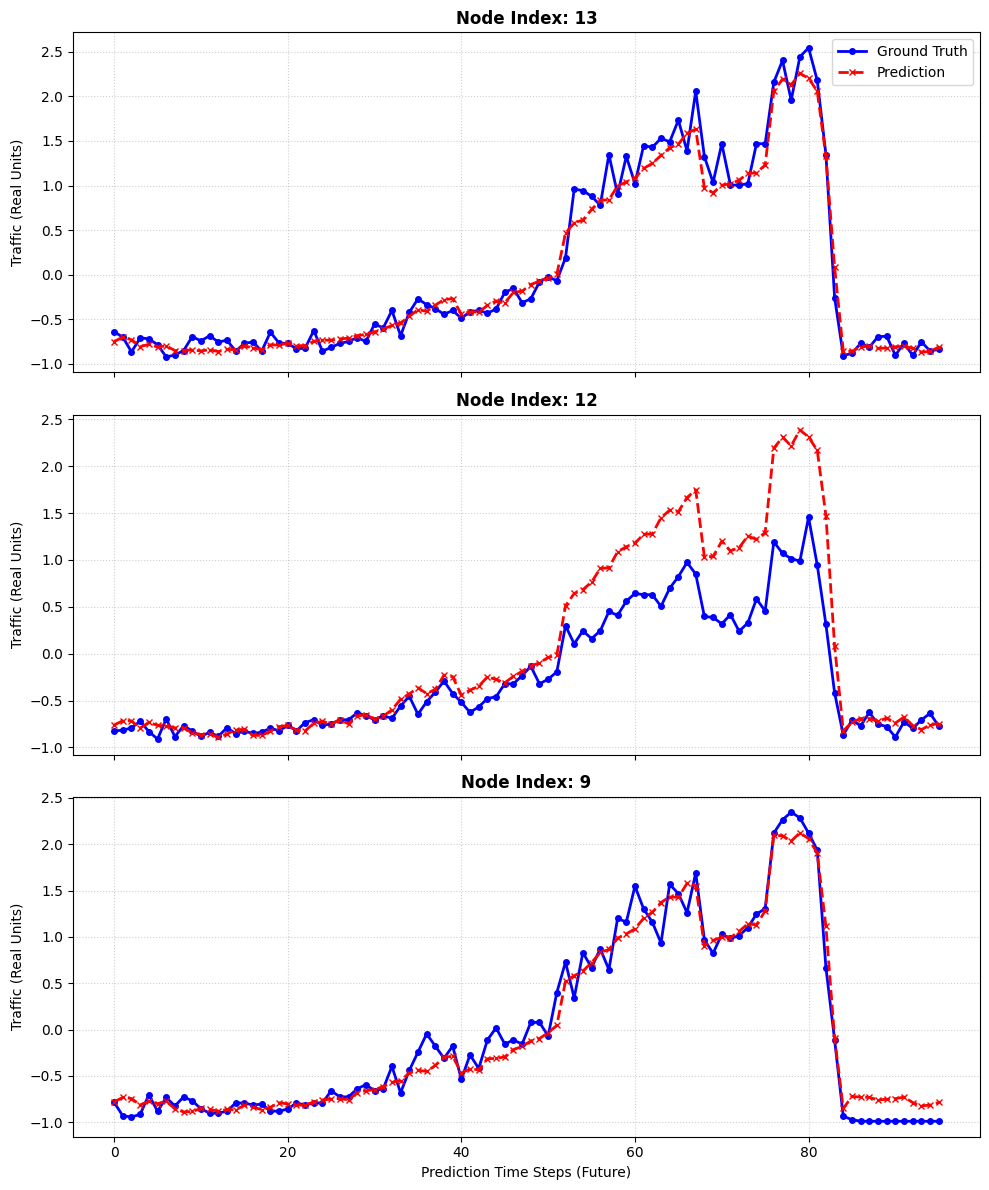

Validation Loss: 0.05401135527063161
Validation MAE: 28.73130171351573
Validation RMSE: 44.04332986051707


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
Loss,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MAE,42.8,42.5,102.4,106.3,44.0,41.3,69.8,45.1,28.7,3.2,9.5,21.5,12.4,44.9,1.9,28.7
RMSE,62.4,61.7,147.1,152.7,63.8,60.6,100.8,67.2,44.0,4.1,14.1,29.4,17.7,64.6,2.9,44.0
max_day,1296.9,1296.9,3736.4,3736.4,1296.9,1235.4,2458.0,1401.0,665.9,67.1,183.2,424.6,179.9,1089.7,23.5,665.9
mean_day,373.1,373.1,1088.6,1088.6,373.1,354.3,715.5,404.4,184.4,18.9,50.9,118.9,50.1,304.6,6.5,184.4
pct_err_%,16.7,16.5,13.5,14.0,17.1,17.1,14.1,16.6,23.9,21.8,27.7,24.7,35.3,21.2,44.2,23.9


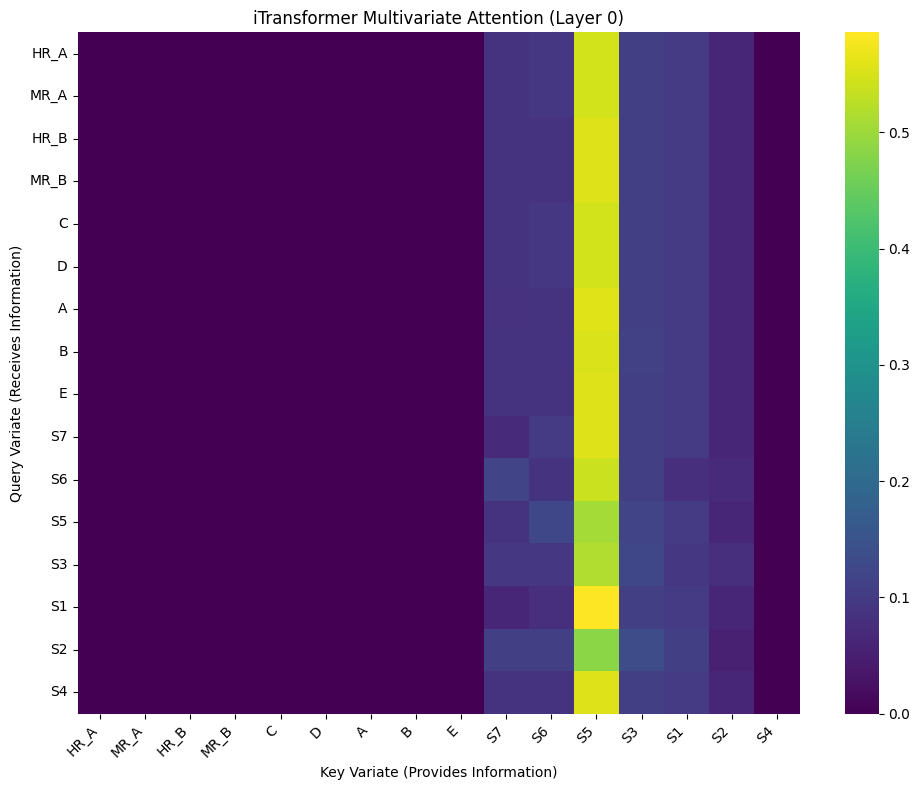

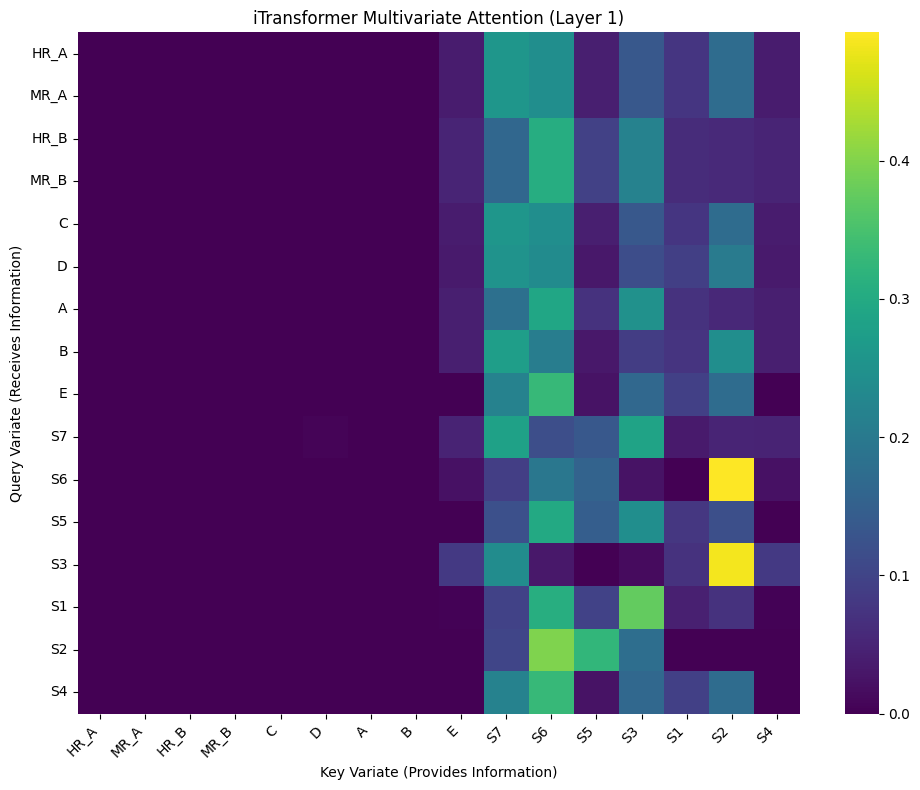

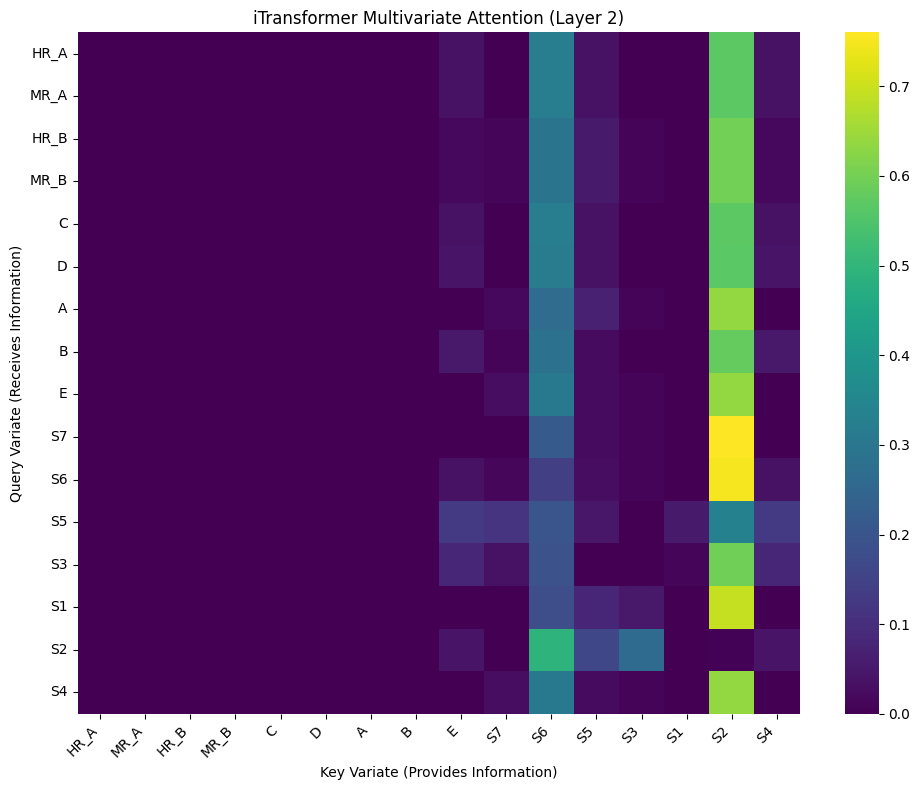

In [86]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
)



PREFIX_MODEL = 'itransformer_model_att_mask'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)

#validate_model(MODEL, TSS_VAL_DL, SCALER, 'cpu')
#validate_plots(MODEL, TSS_TRAIN_DL, SCALER, 'cpu', num_nodes_to_plot=3)
#plot_prediction(MODEL, DATA_RAW_MODEL, HIST_STEPS, PRED_STEPS, 10, SCALER)


criterion = torch.nn.MSELoss()

ERR_TABLE_NODE = []
for i,node in enumerate(NODE_LIST):
    val_loss, val_mae, val_rmse = validate_model(MODEL, TSS_VAL_DL, criterion, SCALER_MEAN_T, SCALER_STD_T, 'cpu', channel=i)
    ERR_TABLE_NODE.append([val_loss, val_mae, val_rmse])

ERR_TABLE_NODE = pd.DataFrame(ERR_TABLE_NODE, columns=['Loss', 'MAE', 'RMSE'], index=NODE_LIST).T
ERR_TABLE_NODE = pd.concat([
    ERR_TABLE_NODE,
    MAX_DAY_NODES, 
    MEAN_DAY_NODES
    ]).round(2)

ERR_TABLE_NODE = pd.concat([
    ERR_TABLE_NODE,
    (ERR_TABLE_NODE.T['RMSE']/ ERR_TABLE_NODE.T['mean_day']).to_frame().rename(columns={0:'pct_err_%'}).T*100
])

ERR_TABLE_NODE = ERR_TABLE_NODE.round(1)

validate_plots(MODEL, TSS_VAL_DL, SCALER_MEAN_T, SCALER_STD_T, 'cpu', num_nodes_to_plot=3)

axs = []
for i in range(LAYERS_ENC_DEC):
    axs.append(analyze_itransformer_attention(MODEL, TSS_VAL_DL, NODE_LIST, layer_index=i, device='cpu')[1])


print(f"Validation Loss: {val_loss}")
print(f"Validation MAE: {val_mae}")
print(f"Validation RMSE: {val_rmse}")
ERR_TABLE_NODE

# SIMULATION

## DATASET FOR RECONSTRUCTION

In [86]:


class MaskedFlowDataset(Dataset):
    def __init__(self, data_scaled, seq_len, inner_mask):
        """
        Args:
            data_scaled (np.ndarray or torch.Tensor): The fully scaled dataset. 
                                                      Shape: (Total_Timesteps, Num_Nodes)
            seq_len (int): The length of the time window (lookback = prediction length).
            inner_mask (torch.Tensor or list): 1 for inner nodes (to be masked out), 
                                               0 for measured leaf nodes. Shape: (Num_Nodes,)
        """
        # Convert data to tensor if it isn't already
        self.data = torch.tensor(data_scaled, dtype=torch.float32)
        self.seq_len = seq_len
        
        # Ensure mask is a boolean tensor for easy indexing
        # True means "this is an inner node, hide it"
        self.inner_mask = torch.tensor(inner_mask, dtype=torch.bool)
        
        # We can generate (Total_Timesteps - seq_len + 1) valid windows
        self.num_samples = len(self.data) - self.seq_len + 1

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 1. Grab the true time window (Target Y)
        # Shape: (seq_len, Num_Nodes)
        window_y = self.data[idx : idx + self.seq_len]
        
        # 2. Create the Input X by copying Y
        window_x = window_y.clone()
        
        # 3. Mask out the inner nodes in X
        # We set them to 0 (which, for StandardScaler data, is exactly the mean)
        # This tells the model: "I have no information about these nodes."
        window_x[:, self.inner_mask] = 0.0
        
        return window_x, window_y

INNER_MASK = (1 - LEAF_NODES_MASK.values)
DATA_RAW_RECON_SCALED = DATA_RAW_MODEL_SCALED.copy()

RECON_DS = MaskedFlowDataset(
    data_scaled=DATA_RAW_RECON_SCALED,
    seq_len=HIST_STEPS,
    inner_mask=INNER_MASK
)
RECON_DL = DataLoader(dataset=RECON_DS, batch_size=32, shuffle=False)

if DEBUG:
    for x_batch, y_batch in RECON_DL:
        if randint(0,10) == 5:
            break

  
    # The 1st timestep of the 2nd window
    print(RECON_DS[1][0][0])
    val_a = RECON_DS[1][0][0] 

    # The 2nd timestep of the 1st window
    print(RECON_DS[0][0][1])
    val_b = RECON_DS[0][0][1] 

 
    

tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.9278, -0.8938, -0.8938, -0.8885, -0.9073, -0.8492, -0.9078])
tensor([ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000, -0.9278, -0.8938, -0.8938, -0.8885, -0.9073, -0.8492, -0.9078])


### TRAINING MASKED

ADJ_MATRIX_T.shape: torch.Size([16, 16])
INCIDENCE_MATRIX_T.shape: torch.Size([9, 16])
torch.Size([32, 24, 16]) torch.Size([32, 24, 16])
tensor(3354.2739, dtype=torch.float64)


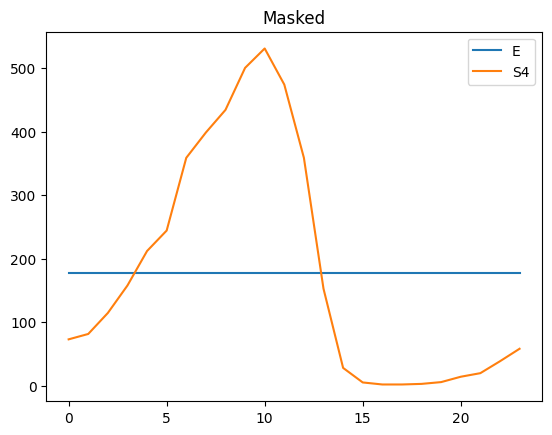

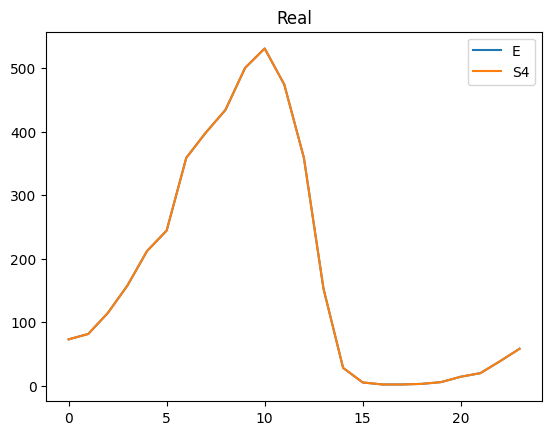

In [87]:
class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        self.adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = self.adj_matrix.sum(dim=1)
        self.parent_mask = (row_sum > 0).float().view(1, 1, -1).to(device)

    def forward(self, Y_pred_real, Y_true_real):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents
        
        F_children = Y_pred_real
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]


        B, T, C = F_children.shape
        F_flat = F_children.reshape(B*T,C)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        F_reference = F_reconstructed_flat.reshape(B, T, C)
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        #diff = Y_pred_real - F_reference
        diff = Y_true_real - F_reference
        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        loss = (diff ** 2) * self.parent_mask
        
        return loss.mean()

class CombinedTrafficLoss(nn.Module):
    def __init__(self, G_physical, scaler_mean, scaler_std, device='cpu', lambda_phy=0.1, lambda_mse=1):
        """
        Args:
            G_physical: NetworkX graph (Parent -> Child edges).
            scaler_mean: The mean used to scale the data.
            scaler_std: The standard deviation used to scale the data.
            device: 'cuda' or 'cpu'.
            lambda_phy: Weighting factor for the physics loss (default 0.1).
        """
        super(CombinedTrafficLoss, self).__init__()
        self.lambda_phy = lambda_phy
        self.lambda_mse = lambda_mse
        self.device = device
        
        # 1. Standard Data Loss (MSE)
        self.mse = nn.MSELoss()
        
        # 2. Physics Loss (Bottom-Up Reconstruction)
        self.bottom_up = BottomUpReconstructionLoss(G_physical, device)
        
        # 3. Stats for Differentiable Reverse Transform
        # We need these to convert Z-scores to Real Flow inside the loss
       
        self.means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
        self.scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)


    def forward(self, Y_pred, Y_true):
        """
        Args:
            Y_pred: Model output (Normalized Z-Scores)
            Y_true: Ground Truth (Normalized Z-Scores)
        """
        B,T,C = Y_true.shape

        # --- 1. Data Loss (MSE) ---
        # Calculated on Normalized data (Standard Deep Learning practice)
        
        loss_data = self.mse(Y_pred, Y_true)
        
        # --- 2. Physics Preparation (Reverse Transform) ---
        # We must un-scale the data to check Flow Conservation.
        # Since this is just (X * std) + mean, it preserves Gradients!
        Y_pred_real = (Y_pred * self.scale) + self.means
        Y_true_real = (Y_true * self.scale) + self.means
        
        # --- 3. Physics Loss (Bottom-Up) ---
        # Calculated on Real Units
        loss_physics = self.bottom_up(Y_pred_real, Y_true_real)
        
        # --- 4. Combine ---
        total_loss = (self.lambda_mse * loss_data) + (self.lambda_phy * loss_physics)


        return total_loss, loss_data, loss_physics
        
if DEBUG:
    SCALER_MEAN_T = torch.tensor(SCALER.mean_)
    SCALER_STD_T = torch.tensor(SCALER.scale_)
    INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX)
    ADJ_MATRIX_T = torch.tensor(ADJ_MATRIX)
    print(f"ADJ_MATRIX_T.shape: {ADJ_MATRIX_T.shape}")
    print(f"INCIDENCE_MATRIX_T.shape: {INCIDENCE_MATRIX_T.shape}")

    parent_mask = (ADJ_MATRIX_T.sum(dim=1) > 0).float().view(1, 1, -1)

    from random import randint
    for batch_idx, (X_scaled_masked, X_scaled_real) in enumerate(RECON_DL):
        if randint(0,10) == 3:
            break

    X_un_masked = (X_scaled_masked * SCALER_STD_T) + SCALER_MEAN_T
    X_un_real = (X_scaled_real * SCALER_STD_T) + SCALER_MEAN_T


    B,T,C = X_un_masked.shape
    print(X_un_masked.shape, X_un_real.shape)

    ax = pd.DataFrame(X_un_masked[0,:,:].numpy(), columns=NODE_LIST)[['E','S4']].plot(title='Masked')
    pd.DataFrame(X_un_real[0,:,:].numpy(), columns=NODE_LIST)[['E','S4']].plot( title='Real')

    X_flows = X_un_masked.reshape(B*T,C)
    F_reconstructed_flat = torch.matmul(X_flows, ADJ_MATRIX_T.T)
    F_reference = F_reconstructed_flat.reshape(B, T, C)
    diff = X_un_masked - F_reference

    print(((diff[0][0]**2)*parent_mask).mean())



In [79]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
).to(DEVICE)


LEAF_NODES_MASK_T = torch.tensor(LEAF_NODES_MASK.values).clone().reshape(1, 1, -1).to(DEVICE)
INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX).clone().to(DEVICE)
SCALER_MEAN_T = torch.tensor(SCALER.mean_).clone().to(DEVICE)
SCALER_STD_T = torch.tensor(SCALER.scale_).clone().to(DEVICE) 



PATIENCE = 10

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, path=CHECKPOINT_PATH)
optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR)

loss_fn = CombinedTrafficLoss(
        G_physical=G_router, 
        scaler_mean=SCALER_MEAN_T, 
        scaler_std=SCALER_STD_T, 
        device=DEVICE, 
        lambda_phy=10
).to(DEVICE)





✔️ Att mask set
Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask_node_sim.pth


### RECONTRSTRUCT GRAHPS

In [80]:
print("Starting Training...")


EPOCHS = 60
for epoch in range(EPOCHS):
    MODEL.train()
    
    # Trackers for the different loss components
    epoch_total_loss = 0.0
    epoch_task_loss = 0.0
    epoch_kcl_loss = 0.0
    
    for batch_idx, (x_batch, y_batch) in enumerate(RECON_DL):
        # Move data to GPU/CPU
        X_scaled_masked = x_batch.to(DEVICE)
        X_scaled = y_batch.to(DEVICE)
        
        # Zero the gradients
        optimizer.zero_grad()
        
        # Forward Pass: Predict the full window (both leaves and inner nodes)
        # x_batch has inner nodes masked to 0.0
        y_pred = MODEL(X_scaled_masked)
        
        # Calculate Loss
        # total_loss drives the optimizer. The others are for our monitoring.
        total_loss, task_loss, kcl_penalty = loss_fn(y_pred, X_scaled)
        
        # Backward Pass & Optimize
        total_loss.backward()
        
        # Optional: Gradient clipping is often helpful for transformers
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update trackers
        epoch_total_loss += total_loss.item()
        epoch_task_loss += task_loss.item()
        epoch_kcl_loss += kcl_penalty.item()
        
    # Calculate averages for the epoch
    num_batches = len(RECON_DL)
    avg_total = epoch_total_loss / num_batches
    avg_task = epoch_task_loss / num_batches
    avg_kcl = epoch_kcl_loss / num_batches
    
    # Print progress
    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Total: {avg_total:.4f} | "
          f"Task (Leaves MSE): {avg_task:.4f} | "
          f"Physics (KCL Violation): {avg_kcl:.4f}")

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Starting Training...
Epoch [1/60] Total: 363590.9983 | Task (Leaves MSE): 0.2293 | Physics (KCL Violation): 36359.0768
Epoch [2/60] Total: 113739.1281 | Task (Leaves MSE): 0.1077 | Physics (KCL Violation): 11373.9021
Epoch [3/60] Total: 101442.5305 | Task (Leaves MSE): 0.1002 | Physics (KCL Violation): 10144.2430
Epoch [4/60] Total: 94792.6469 | Task (Leaves MSE): 0.0957 | Physics (KCL Violation): 9479.2551
Epoch [5/60] Total: 89905.1140 | Task (Leaves MSE): 0.0921 | Physics (KCL Violation): 8990.5021
Epoch [6/60] Total: 87105.2384 | Task (Leaves MSE): 0.0892 | Physics (KCL Violation): 8710.5149
Epoch [7/60] Total: 83970.1563 | Task (Leaves MSE): 0.0862 | Physics (KCL Violation): 8397.0070
Epoch [8/60] Total: 80485.3604 | Task (Leaves MSE): 0.0830 | Physics (KCL Violation): 8048.5277
Epoch [9/60] Total: 77513.6624 | Task (Leaves MSE): 0.0798 | Physics (KCL Violation): 7751.3582
Epoch [10/60] Total: 75769.2282 | Task (Leaves MSE): 0.0771 | Physics (KCL Violation): 7576.9151
Epoch [11/60

### RECONSTRUCTION OF FLOWS

In [88]:
MODEL = iTransformer(
        num_variates=NUM_NODES,
        hist_steps=HIST_STEPS,
        pred_steps=PRED_STEPS,
        d_model=D_MODEL,   
        num_layers=LAYERS_ENC_DEC,  
        n_heads=K_HEADS,
        attn_mask=ATT_MASK_T
)

PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




✔️ Att mask set
Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_trained.pth


<All keys matched successfully>

## SCENARIOS: WHAT IFS

In [94]:
def reconstruct_physical_flow(model, dataloader, scaler_means, scaler_stds, device='cpu'):
    """
    Runs inference to reconstruct masked inner nodes (state estimation).
    Extracts the final timestep of each sliding window to build a continuous timeline.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: Continuous reconstructed predictions. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: Continuous true values. Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    # Reshape scalers for broadcasting: (1, 1, Num_Nodes)
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x, y in dataloader:
            x_scaled_maked = x.to(device)
            x_scaled = y.to(device)
            
            # 1. Forward pass: Reconstruct the current masked window
            x_pred_scaled = model(x_scaled_maked)
            
            # 2. Unscale back to physical flow units
            x_pred_unscaled = (x_pred_scaled * stds) + means    
            x_unscaled = (x_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = x_pred_unscaled.cpu().numpy()
            trues_np = x_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)
            # Shape goes from (Batch, Seq_Len, Nodes) -> (Batch, Nodes)
            step_preds = preds_np[:, -1, :]
            step_trues = trues_np[:, -1, :]
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # 4. Concatenate all batches vertically into a single continuous 2D array
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    return final_preds, final_trues

def reconstruct_physical_flow_mask(model, dataloader, scaler_means, scaler_stds, inner_mask, device='cpu'):
    """
    Reconstructs the timeline by merging ground truth leaf nodes with predicted inner nodes.
    
    Args:
        model (nn.Module): The trained iTransformer.
        dataloader (DataLoader): DataLoader using the MaskedFlowDataset.
        scaler_means (torch.Tensor): Means from StandardScaler. Shape: (num_nodes,)
        scaler_stds (torch.Tensor): Stds from StandardScaler. Shape: (num_nodes,)
        inner_mask (list or np.ndarray): 1 (or True) for inner nodes, 0 for leaf nodes.
        device (str): 'cpu' or 'cuda'.
        
    Returns:
        np.ndarray: The merged physical flows. Shape: (Total_Timesteps, Num_Nodes)
        np.ndarray: The original true flows (for reference). Shape: (Total_Timesteps, Num_Nodes)
    """
    model.eval()
    model.to(device)
    
    means = scaler_means.float().to(device).view(1, 1, -1)
    stds = scaler_stds.float().to(device).view(1, 1, -1)
    
    # Ensure the mask is a boolean numpy array for easy indexing later
    mask_np = np.array(inner_mask, dtype=bool)
    
    continuous_preds = []
    continuous_trues = []
    
    with torch.no_grad():
        for x, y_true_scaled in dataloader:
            x = x.to(device)
            y_true_scaled = y_true_scaled.to(device)
            
            # 1. Forward pass
            y_pred_scaled = model(x)
            
            # 2. Unscale back to physical flow units
            y_pred_unscaled = (y_pred_scaled * stds) + means
            y_true_unscaled = (y_true_scaled * stds) + means
            
            # Move to CPU and convert to NumPy
            preds_np = y_pred_unscaled.cpu().numpy()
            trues_np = y_true_unscaled.cpu().numpy()
            
            # 3. Extract the "Present" (The last timestep of the window)
            step_preds = preds_np[:, -1, :]
            step_trues = trues_np[:, -1, :]
            
            continuous_preds.append(step_preds)
            continuous_trues.append(step_trues)
            
    # Concatenate all batches vertically
    final_preds = np.concatenate(continuous_preds, axis=0)
    final_trues = np.concatenate(continuous_trues, axis=0)
    
    # ---------------------------------------------------------
    # 4. MERGE TRUES AND PREDICTIONS
    # ---------------------------------------------------------
    # Start with a copy of the perfect ground truth data
    merged_flows = final_trues.copy()
    
    # Overwrite ONLY the inner nodes with the model's predictions
    # mask_np is True for inner nodes, False for leaf nodes
    merged_flows[:, mask_np] = final_preds[:, mask_np]
    
    return merged_flows, final_trues




def validate_kcl_compliance(predicted_flows, adjacency_matrix, inner_mask):
    """
    Checks how well the reconstructed flows obey Flow In = Flow Out at the inner nodes.
    
    Args:
        predicted_flows (np.ndarray): The unscaled model outputs. Shape: (Timesteps, Nodes)
        adjacency_matrix (np.ndarray or list): The A matrix. Shape: (Nodes, Nodes)
        inner_mask (np.ndarray or list): Boolean mask for inner nodes. Shape: (Nodes,)
    """
    # 1. Ensure everything is a NumPy array
    Y = np.array(predicted_flows)
    A = np.array(adjacency_matrix)
    mask = np.array(inner_mask, dtype=bool)
    
    # 2. Calculate Flow In and Flow Out for the entire network
    # Matrix multiplication: (Timesteps, Nodes) @ (Nodes, Nodes) -> (Timesteps, Nodes)
    flow_in = Y @ A 
    flow_out = Y
    
    # 3. Calculate the absolute violation (Error) at every timestep
    # We only care about the inner nodes, so we slice using the mask
    inner_flow_in = flow_in[:, mask]
    inner_flow_out = flow_out[:, mask]
    
    violations = np.abs(inner_flow_in - inner_flow_out)
    
    # 4. Report the metrics
    mean_violation = np.mean(violations)
    max_violation = np.max(violations)
    
    print("--- Physics Validation Report ---")
    print(f"Number of Inner Nodes Checked: {sum(mask)}")
    print(f"Total Timesteps Checked: {Y.shape[0]}")
    print(f"Average KCL Violation (Error): {mean_violation:.4f} units of flow")
    print(f"Maximum Single-Step Violation: {max_violation:.4f} units of flow")
    
    return violations

def plot_inner_node_physics(predicted_flows, adjacency_matrix, node_idx, node_name=None, time_range=None):
    """
    Plots the reconstructed flow of a specific inner node alongside its KCL violation.
    
    Args:
        predicted_flows (np.ndarray): The continuous unscaled predictions. Shape: (Timesteps, Nodes)
        adjacency_matrix (np.ndarray): The A matrix mapping flow direction. Shape: (Nodes, Nodes)
        node_idx (int): The index of the inner node you want to visualize.
        time_range (tuple): Optional (start, end) indices to zoom in on a specific time window.
        node_name:  Name of the node analysed
    """
    Y = np.array(predicted_flows)
    A = np.array(adjacency_matrix)
    
    # 1. Calculate Flow In and Flow Out for this specific node
    # Flow In = The sum of flows from all upstream nodes pointing to node_idx
    # We get this by multiplying the full flow matrix by the specific column for node_idx in A
    flow_in = Y @ A[:, node_idx] 
    
    # Flow Out = The model's prediction for this node itself
    flow_out = Y[:, node_idx]
    
    # KCL Violation (Absolute Error)
    kcl_error = np.abs(flow_in - flow_out)
    
    # 2. Handle zooming in on a specific time window
    if time_range is not None:
        start, end = time_range
        flow_in = flow_in[start:end]
        flow_out = flow_out[start:end]
        kcl_error = kcl_error[start:end]
        time_steps = np.arange(start, end)
    else:
        time_steps = np.arange(len(Y))
        
    # 3. Create the plot
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True, 
                                   gridspec_kw={'height_ratios': [3, 1]})
    
    # Top Subplot: Flow In vs Flow Out
    ax1.plot(time_steps, flow_in, label="Flow IN (Sum of upstream nodes)", 
             color='#1f77b4', linewidth=2, alpha=0.8)
    ax1.plot(time_steps, flow_out, label=f"Flow OUT (Reconstructed Node {node_idx})", 
             color='#ff7f0e', linewidth=2, linestyle='--')
    
    ax1.set_title(f"Physics Validation: Inner Node {node_name}", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Physical Flow Volume", fontsize=12)
    ax1.legend(loc="upper right", fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Bottom Subplot: KCL Error
    ax2.plot(time_steps, kcl_error, label="KCL Violation (|In - Out|)", 
             color='#d62728', linewidth=1.5)
    ax2.fill_between(time_steps, 0, kcl_error, color='#d62728', alpha=0.2)
    
    ax2.set_xlabel("Timestep", fontsize=12)
    ax2.set_ylabel("Absolute Error", fontsize=12)
    ax2.legend(loc="upper right", fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


## NO MODIFICATION

Recon size: 97
--- Physics Validation Report ---
Number of Inner Nodes Checked: 9
Total Timesteps Checked: 97
Average KCL Violation (Error): 408.5460 units of flow
Maximum Single-Step Violation: 1431.5054 units of flow


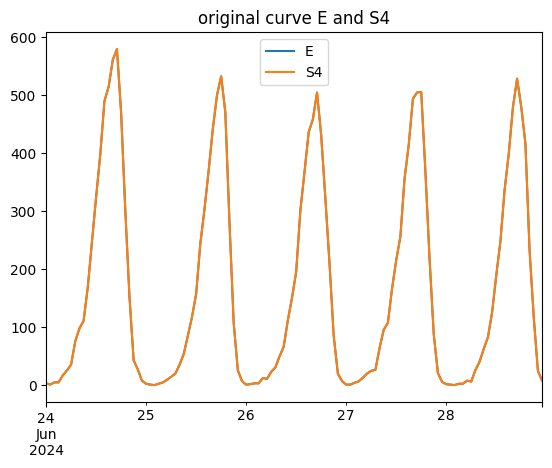

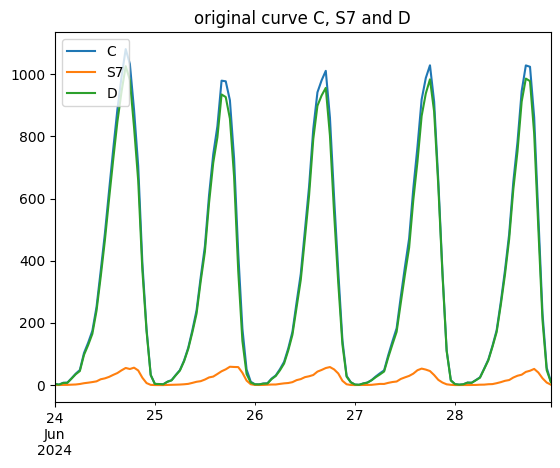

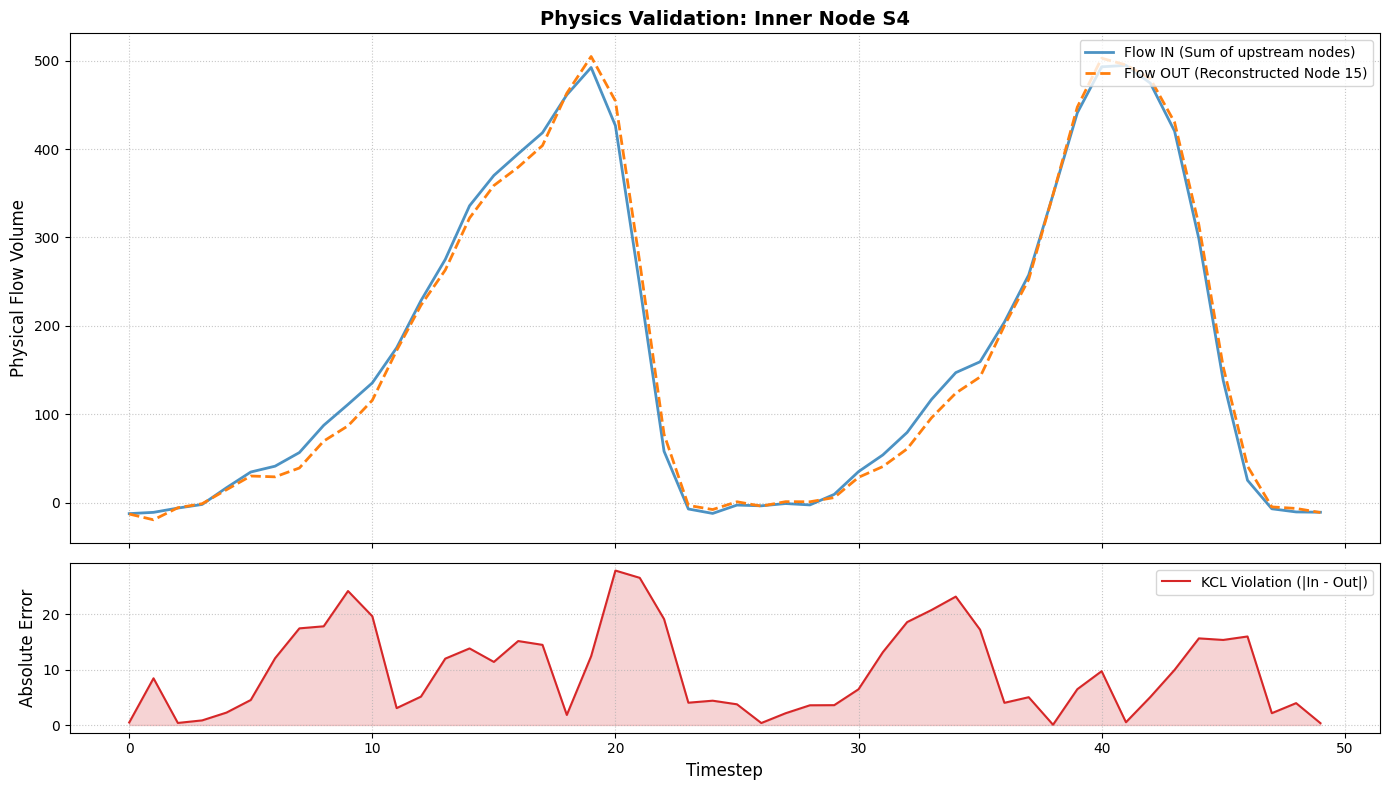

Validation Complete.
MAE:  165.4877 (Real Units)
RMSE: 377.5141 (Real Units)
MAPE: 496.87%
📊 Visualization for Batch Sample #14


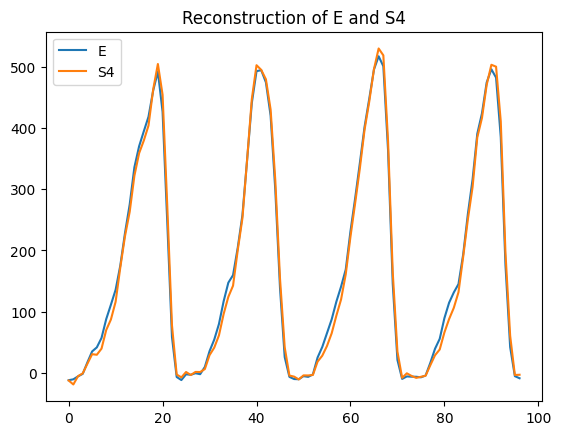

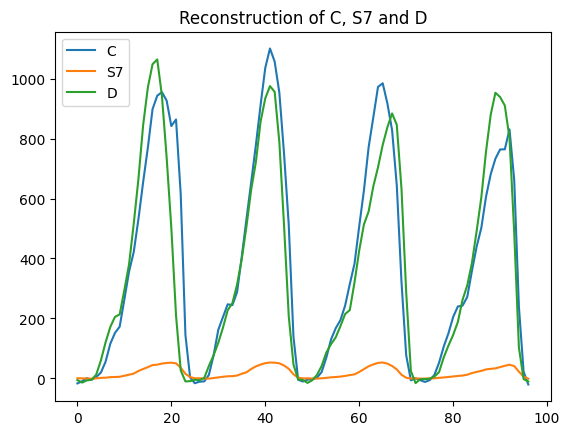

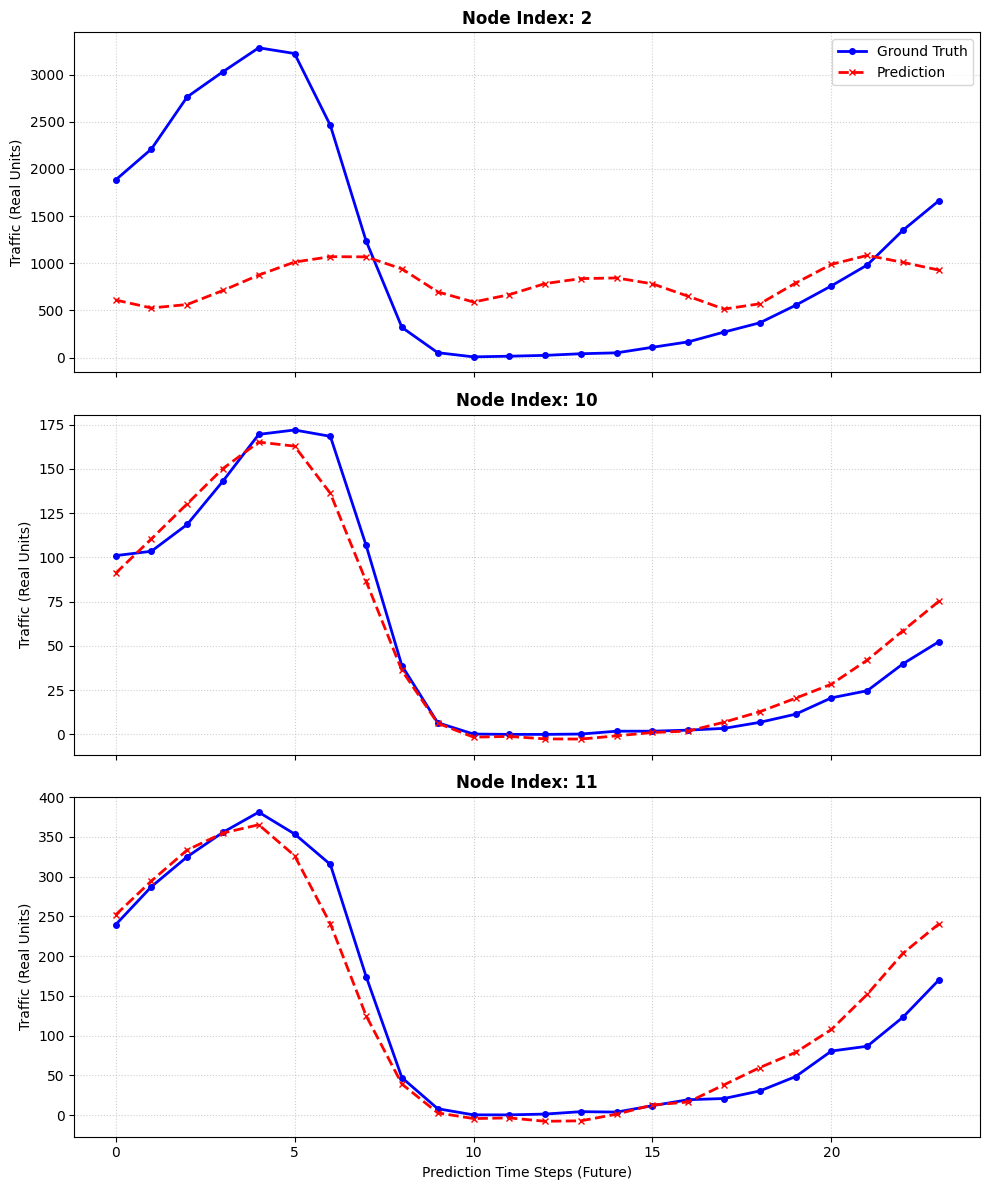

In [96]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,

    device='cpu'
)

violation_history = validate_kcl_compliance(
    predicted_flows, 
    ADJ_MATRIX, 
    INNER_MASK
)

plot_inner_node_physics(
    predicted_flows=predicted_flows, 
    adjacency_matrix=ADJ_MATRIX, 
    node_idx=NODE_TO_IDX['S4'], 
    node_name='S4',
    time_range=(0, 50) 
)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
validate_model(MODEL, RECON_DL, SCALER, 'cpu')
validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)

## WHATF IF S4 increase to 1.5

Recon size: 97
--- Physics Validation Report ---
Number of Inner Nodes Checked: 9
Total Timesteps Checked: 97
Average KCL Violation (Error): 404.2264 units of flow
Maximum Single-Step Violation: 1404.2642 units of flow


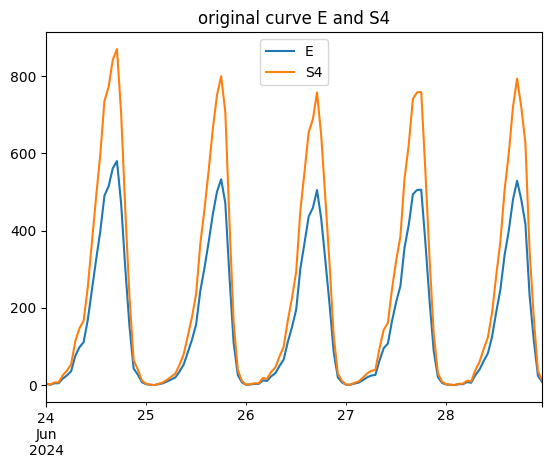

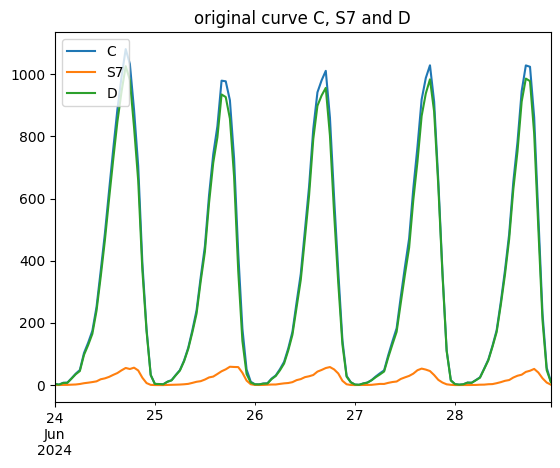

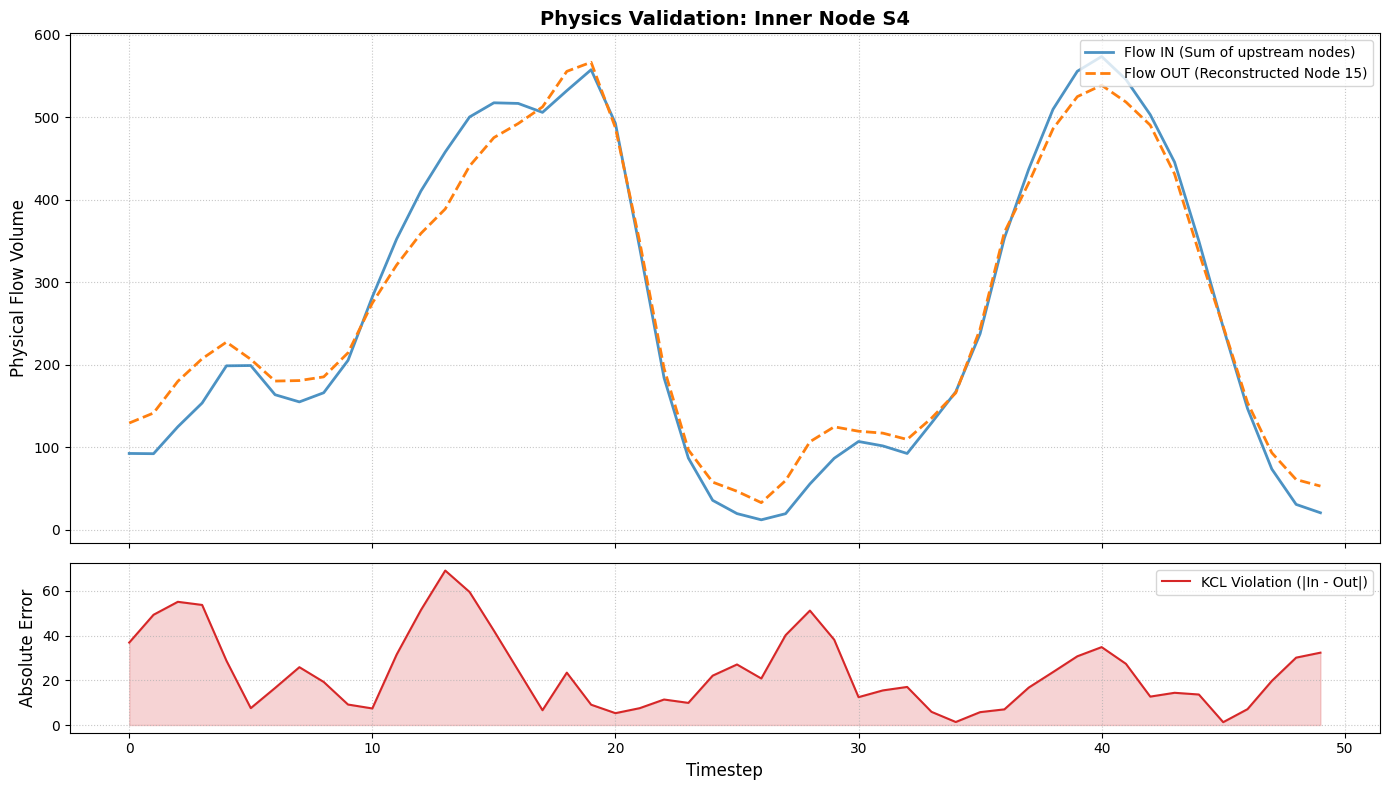

Validation Complete.
MAE:  165.4877 (Real Units)
RMSE: 377.5141 (Real Units)
MAPE: 496.87%
📊 Visualization for Batch Sample #0


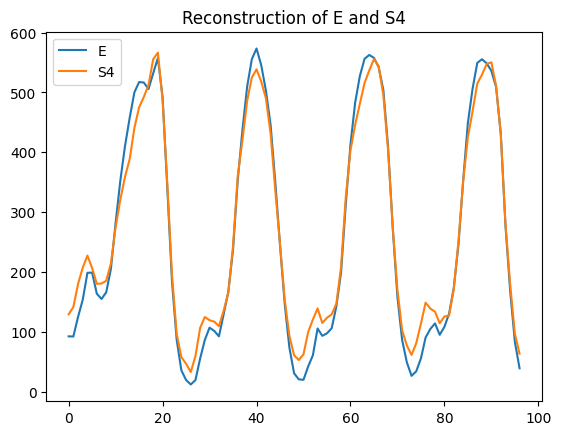

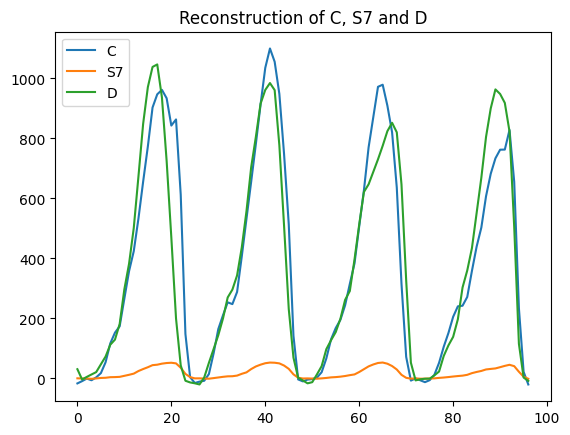

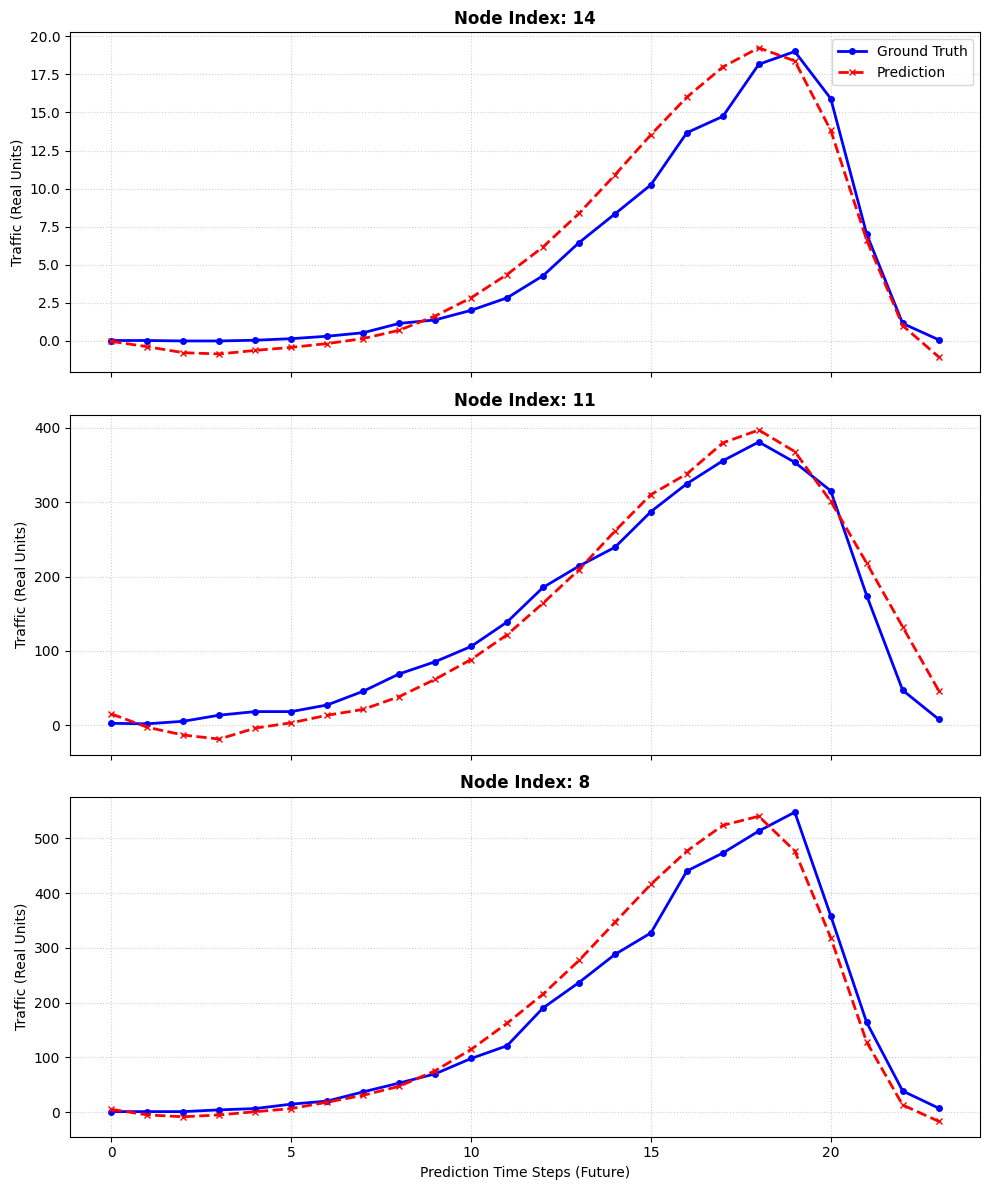

In [97]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]
DATA_RAW_SIMULATION['S4'] *= 1.5


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,
    device='cpu'
)

violation_history = validate_kcl_compliance(
    predicted_flows, 
    ADJ_MATRIX, 
    INNER_MASK
)

plot_inner_node_physics(
    predicted_flows=predicted_flows, 
    adjacency_matrix=ADJ_MATRIX, 
    node_idx=NODE_TO_IDX['S4'], 
    node_name='S4',
    time_range=(0, 50) 
)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
validate_model(MODEL, RECON_DL, SCALER, 'cpu')
validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)

## WHAT IF S4 down in 0.5

Recon size: 97
--- Physics Validation Report ---
Number of Inner Nodes Checked: 9
Total Timesteps Checked: 97
Average KCL Violation (Error): 417.2630 units of flow
Maximum Single-Step Violation: 1439.4943 units of flow


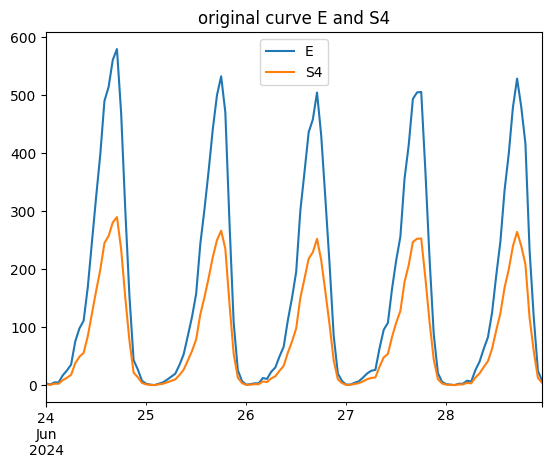

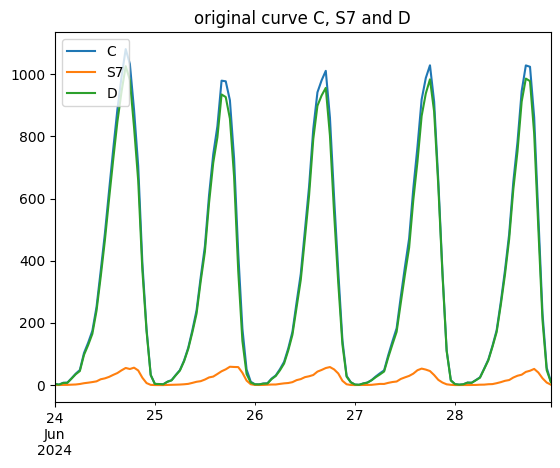

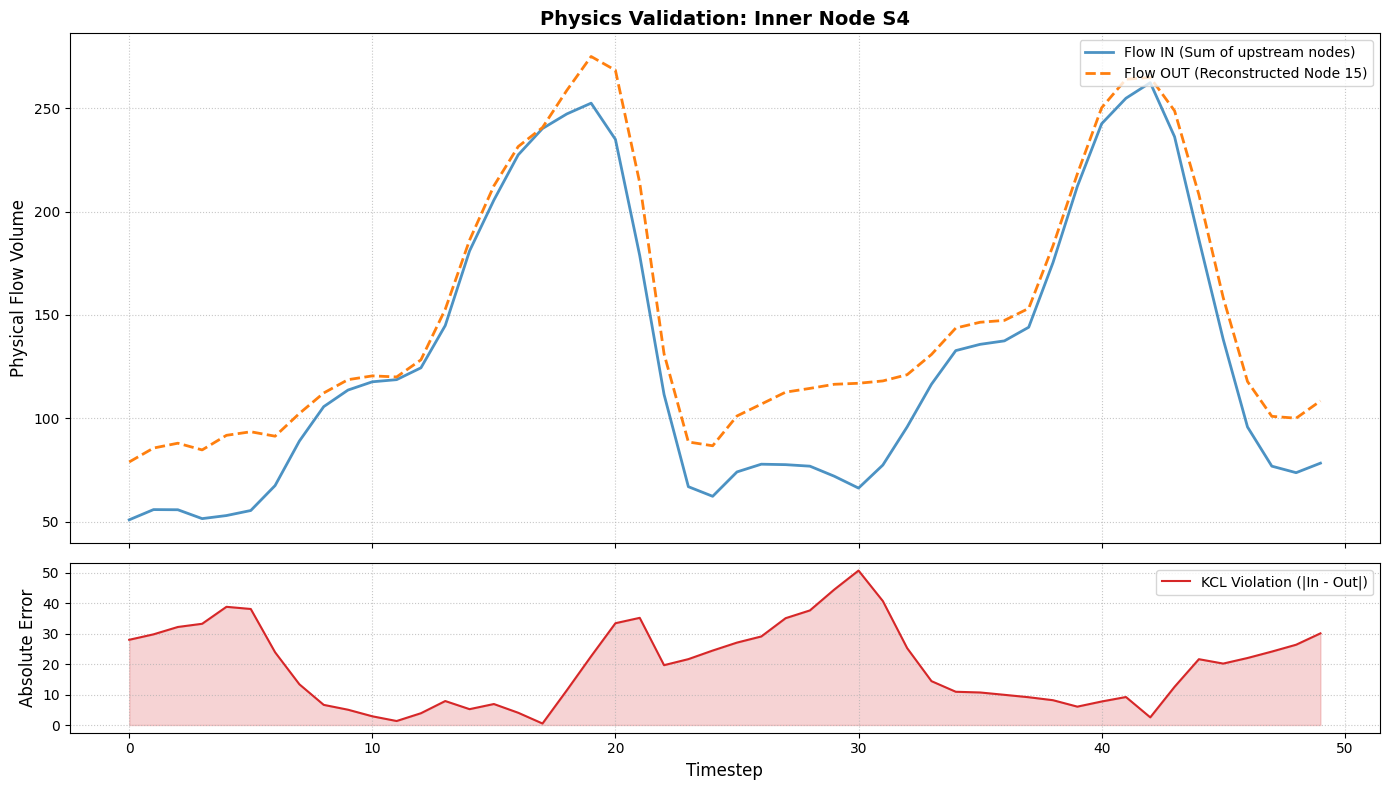

Validation Complete.
MAE:  165.4877 (Real Units)
RMSE: 377.5141 (Real Units)
MAPE: 496.87%
📊 Visualization for Batch Sample #12


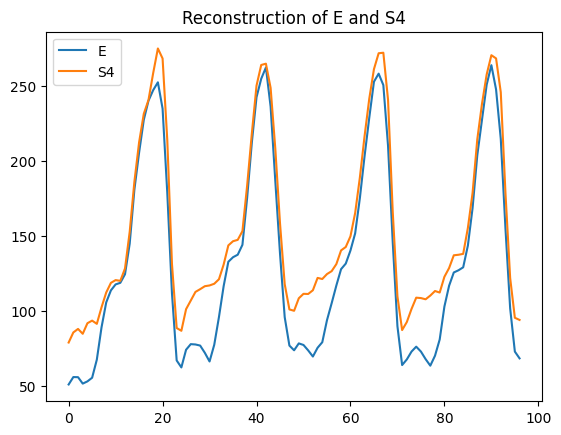

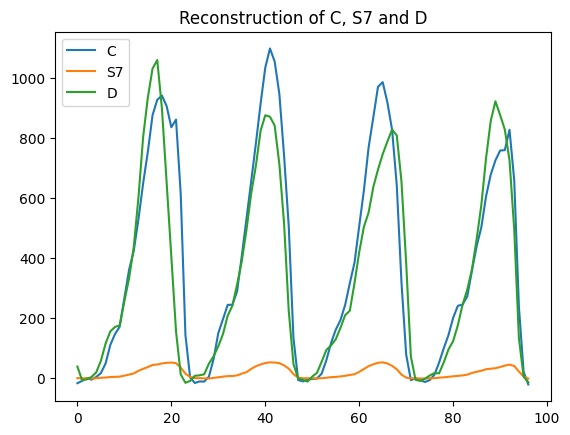

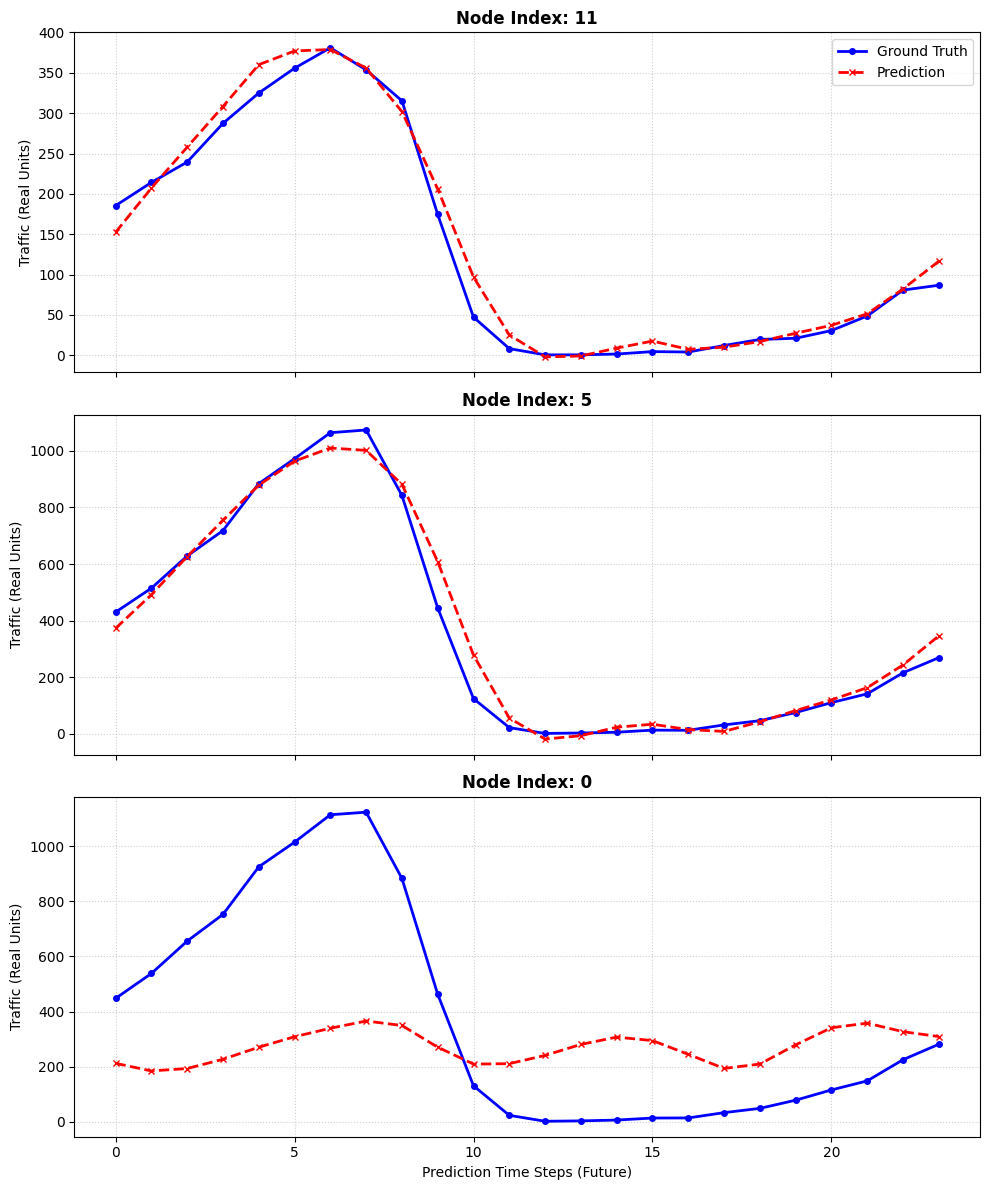

In [98]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[-HIST_STEPS*5:,:]
DATA_RAW_SIMULATION['S4'] *= 0.5


recon_data = SCALER.transform(DATA_RAW_SIMULATION.values)
SIM_DS = MaskedFlowDataset(recon_data, seq_len=HIST_STEPS, inner_mask=INNER_MASK)
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)
print(f"Recon size: {len(SIM_DS)}")

DATA_RAW_SIMULATION[['E','S4']].plot(title='original curve E and S4')
DATA_RAW_SIMULATION[['C','S7','D']].plot(title='original curve C, S7 and D')


predicted_flows, true_flows = reconstruct_physical_flow(
    model=MODEL,
    dataloader=SIM_DL,
    scaler_means=SCALER_MEAN_T,
    scaler_stds=SCALER_STD_T,
    device='cpu'
)

violation_history = validate_kcl_compliance(
    predicted_flows, 
    ADJ_MATRIX, 
    INNER_MASK
)

plot_inner_node_physics(
    predicted_flows=predicted_flows, 
    adjacency_matrix=ADJ_MATRIX, 
    node_idx=NODE_TO_IDX['S4'], 
    node_name='S4',
    time_range=(0, 50) 
)

pd.DataFrame(predicted_flows, columns=NODE_LIST)[['E','S4']].plot(title='Reconstruction of E and S4')
pd.DataFrame(predicted_flows, columns=NODE_LIST)[['C','S7','D']].plot(title='Reconstruction of C, S7 and D')
validate_model(MODEL, RECON_DL, SCALER, 'cpu')
validate_plots(MODEL, RECON_DL, SCALER, 'cpu', num_nodes_to_plot=3)